In [1]:
pwd

'/ictstr01/home/icb/ghaith.mqawass'

In [2]:
cd projs/morflow2.0/

/ictstr01/home/icb/ghaith.mqawass/projs/morflow2.0


In [25]:
# from sampling.samplers import  sample_flow,sample_flow_custom
from modules.lit_model import FlowMolBERTLitModule
from configs import *
from utils.metrics import compute_smiles_metrics,decode_tokens_to_smiles
from utils.sample import generate_mols

/lustre/groups/ml01/workspace/ghaith.mqawass/flow/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [39]:
checkpoint_path = '/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/checkpoints/CrossEntropyLoss()_L=72_uniform_layers=12_dim=768_best-validity-epoch=121-validity=0.9350.ckpt'
model = FlowMolBERTLitModule.load_from_checkpoint(checkpoint_path)

/lustre/groups/ml01/workspace/ghaith.mqawass/flow/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:209: Attribute 'loss_fn' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss_fn'])`.


In [40]:
dfm = model.model
dfm.eval()

FlowMolBERT(
  (tok_emb): Embedding(173, 767)
  (pos_emb): Embedding(72, 767)
  (time_emb): Linear(in_features=1, out_features=1, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (linear1): Linear(in_features=768, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=768, bias=True)
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (lm_head): Linear(in_features=768, out_features=173, bias=False)
)

In [41]:
torch.cuda.empty_cache()

In [46]:
torch.cuda.empty_cache()

In [142]:
import GPUtil

GPUs = GPUtil.getGPUs()
torch.cuda.empty_cache()
for gpu in GPUs:
    print(f"GPU id: {gpu.id}, name: {gpu.name}")
    print(f"  Memory Free: {gpu.memoryFree} MB")
    print(f"  Memory Used: {gpu.memoryUsed} MB")
    print(f"  Memory Total: {gpu.memoryTotal} MB")
    print(f"  GPU Load: {gpu.load*100}%")


GPU id: 0, name: NVIDIA A100-PCIE-40GB
  Memory Free: 22058.0 MB
  Memory Used: 18385.0 MB
  Memory Total: 40960.0 MB
  GPU Load: nan%


In [43]:
from tqdm import tqdm 
import torch
SEED = 50
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
val =[]
div = []
uniqueness = []
temps = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8 , 0.9, 1]
for t in  tqdm(temps):
    samples = generate_mols(dfm, num_samples=1000,steps=100, device = 'cuda', temperature=t)
    total_samples = len(samples)
    _, smiles = decode_tokens_to_smiles(samples, ID2TOK=ID2TOK, TOK2ID=TOK2ID, PAD=PAD)
    metrics = compute_smiles_metrics(total_samples=total_samples, decoded_smiles=smiles)
    val.append(metrics['validity'])
    div.append(metrics['diversity'])
    uniqueness.append(metrics['uniqueness'])
    torch.cuda.empty_cache()


NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:30<00:00, 150.61s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 148.04s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 147.75s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:28<00:00, 148.97s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 147.77s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 147.77s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 147.81s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 147.87s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 147.78s/it]
NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [02:27<00:00, 148.01s/it]
100%|██████████| 10/10 [25:08<00:00, 150.85s/it]


In [45]:
metrics

{'validity': 0.917,
 'uniqueness': 1.0,
 'diversity': np.float64(0.8846398036814432)}

In [11]:
metrics # {'validity': 0.967,   400 steps, temprature = 0.5
 #'uniqueness': 0.9958634953464323,
 #'diversity': np.float64(0.8697108141226302)}

{'validity': 0.967,
 'uniqueness': 0.9958634953464323,
 'diversity': np.float64(0.8697108141226302)}

In [46]:
div

[np.float64(0.8560036656460205),
 np.float64(0.8576683947104858),
 np.float64(0.8647830143044196),
 np.float64(0.8700894568164708),
 np.float64(0.8754440175480954),
 np.float64(0.8772035588949698),
 np.float64(0.8800892612217822),
 np.float64(0.8817270657551914),
 np.float64(0.8845820565143137),
 np.float64(0.8846398036814432)]

In [47]:
val

[0.927, 0.95, 0.94, 0.944, 0.944, 0.939, 0.949, 0.934, 0.904, 0.917]

In [48]:
uniqueness

[0.9892125134843581,
 0.991578947368421,
 0.9968085106382979,
 1.0,
 1.0,
 1.0,
 0.9989462592202318,
 1.0,
 1.0,
 1.0]

In [159]:
# import pandas as pd
# df_generated = pd.DataFrame(smiles, columns=['smiles'])
# df_generated.to_parquet("/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/df5k_generated4.parquet")

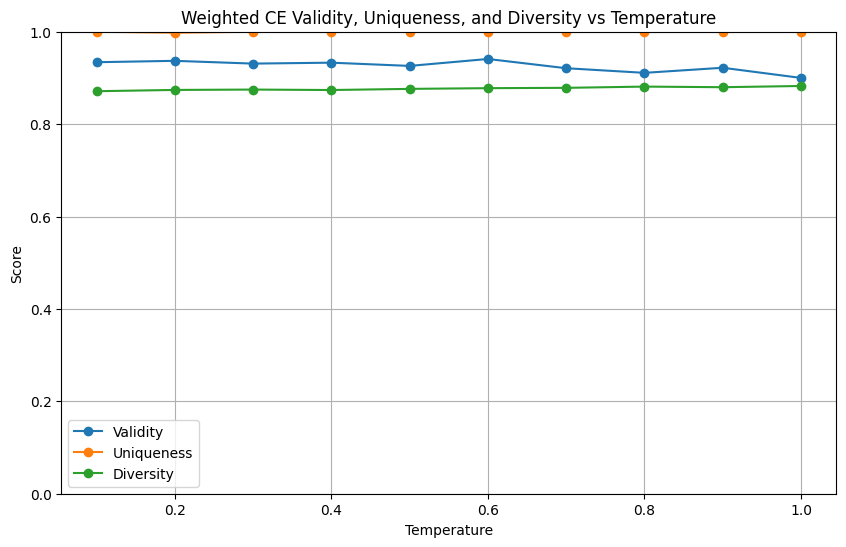

In [37]:
import matplotlib.pyplot as plt

# Example data
temperatures = [0.1 * i for i in range(1, 11)]  # [0.1, 0.2, ..., 1.0]
validity =    val
uniqueness =  uniqueness
diversity =   div

# Plot
plt.figure(figsize=(10, 6))

plt.plot(temperatures, validity, 'o-', label='Validity')
plt.plot(temperatures, uniqueness, 'o-', label='Uniqueness')
plt.plot(temperatures, diversity, 'o-', label='Diversity')

# Labels and title
plt.xlabel('Temperature')
plt.ylabel('Score')
plt.title('Weighted CE Validity, Uniqueness, and Diversity vs Temperature')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

# Show plot
plt.show()


### Properties evaluation

In [227]:
import swifter
import safe
import pandas as pd
from safe import encode, split, SAFEFragmentationError
from rdkit import Chem

In [229]:

df_main = pd.read_parquet('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/data/df_with_chem_props.parquet')
df_gen1 = pd.read_parquet('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/df5k_generated_with_props.parquet')
df_gen2 = pd.read_parquet('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/df5k_generated2_with_props.parquet')
df_gen3 = pd.read_parquet('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/df5k_generated3_with_props.parquet')
df_gen4 = pd.read_parquet('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/df5k_generated4_with_props.parquet')

In [231]:
def tokenize_and_pad_smiles_safe(smiles: str, max_len: int = 72) -> list[str]:
    try:
        encoded = encode(smiles)
        tokens = split(encoded)
        padded = tokens[:max_len] + [' '] * (max_len - len(tokens))
        return padded
    except Exception as e:  # Can also catch SAFEFragmentationError specifically
        # Return a special token list or empty padding if encoding fails
        return ['<ERR>'] + [''] * (max_len - 1)
def count_fragments(tokens: list[str]) -> int:
    return tokens.count('.') + 1 

def count_connected_components(smiles: str) -> int:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0
    return len(Chem.GetMolFrags(mol))

In [232]:
df_gen = pd.concat([df_gen1,df_gen2,df_gen3,df_gen4],ignore_index=True)

In [236]:
df_gen['safe_tokens']= df_gen['smiles'].swifter.apply(tokenize_and_pad_smiles_safe)
df_gen['num_fragments']= df_gen['safe_tokens'].swifter.apply(count_fragments)
df_gen['num_components']= df_gen['smiles'].swifter.apply(count_connected_components)

Pandas Apply: 100%|██████████| 18395/18395 [00:03<00:00, 5965.22it/s]


In [248]:
df_main['num_fragments']= df_main['safe_tokens'].swifter.apply(count_fragments)
df_main['num_components']= df_main['SMILES_standard'].swifter.apply(count_connected_components)

Pandas Apply: 100%|██████████| 1461513/1461513 [03:38<00:00, 6689.60it/s]


In [249]:
df_main = df_main[df_main.seq_len<=MAX_LEN]

In [250]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Step 1: Flatten all tokens into one list
all_tokens_gen = [token for row in df_gen['safe_tokens'] for token in row]
all_tokens_orig = [
    token for row in df_main['safe_tokens']
    for token in row if token not in {',', "'",']','['}
]
token_counts_gen = Counter(all_tokens_gen)
token_counts_orig = Counter(all_tokens_orig)
token_df = pd.DataFrame.from_dict(token_counts_orig, orient='index', columns=['count'])
token_df.sort_values('count', ascending=False, inplace=True)
token_df['probability'] = token_df['count'] / token_df['count'].sum()
token_df_gen = pd.DataFrame.from_dict(token_counts_gen, orient='index', columns=['count'])
token_df_gen.sort_values('count', ascending=False, inplace=True)
token_df_gen['probability'] = token_df_gen['count'] / token_df_gen['count'].sum()


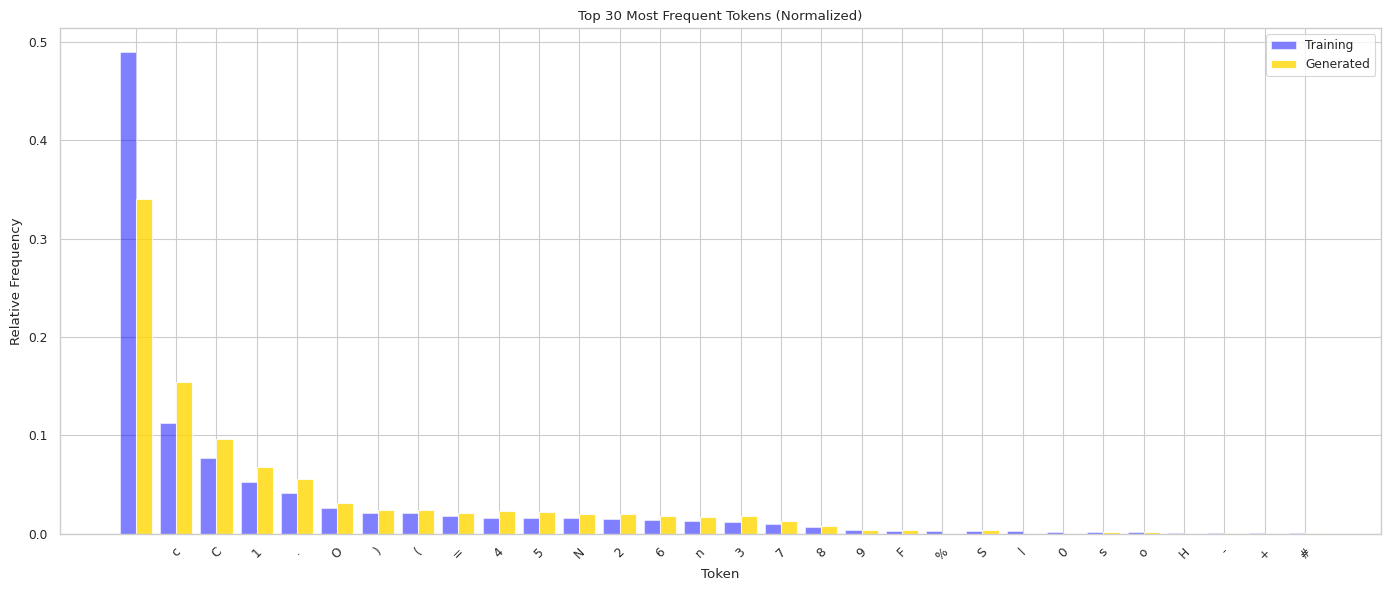

In [255]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# sns.set(style='whitegrid', context='talk', palette='deep') 
sns.set_context("paper")
 
# Align both to same top N tokens
top_n = 30
top_tokens = token_df.sort_values(by='probability', ascending=False).head(top_n).index
orig_top = token_df.reindex(top_tokens).fillna(0)
gen_top = token_df_gen.reindex(top_tokens).fillna(0)

# Set positions
x = np.arange(len(top_tokens))  # the label locations
width = 0.4  # width of the bars

# Create plot
fig, ax = plt.subplots(figsize=(14, 6))
bar1 = ax.bar(x - width/2, orig_top['probability'], width, label='Training', color='blue', alpha=0.5)
bar2 = ax.bar(x + width/2, gen_top['probability'], width, label='Generated', color='gold', alpha=0.8)

# Labels, legend, etc.
ax.set_title('Top 30 Most Frequent Tokens (Normalized)')
ax.set_xlabel('Token')
ax.set_ylabel('Relative Frequency')
ax.set_xticks(x)
ax.set_xticklabels(top_tokens, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


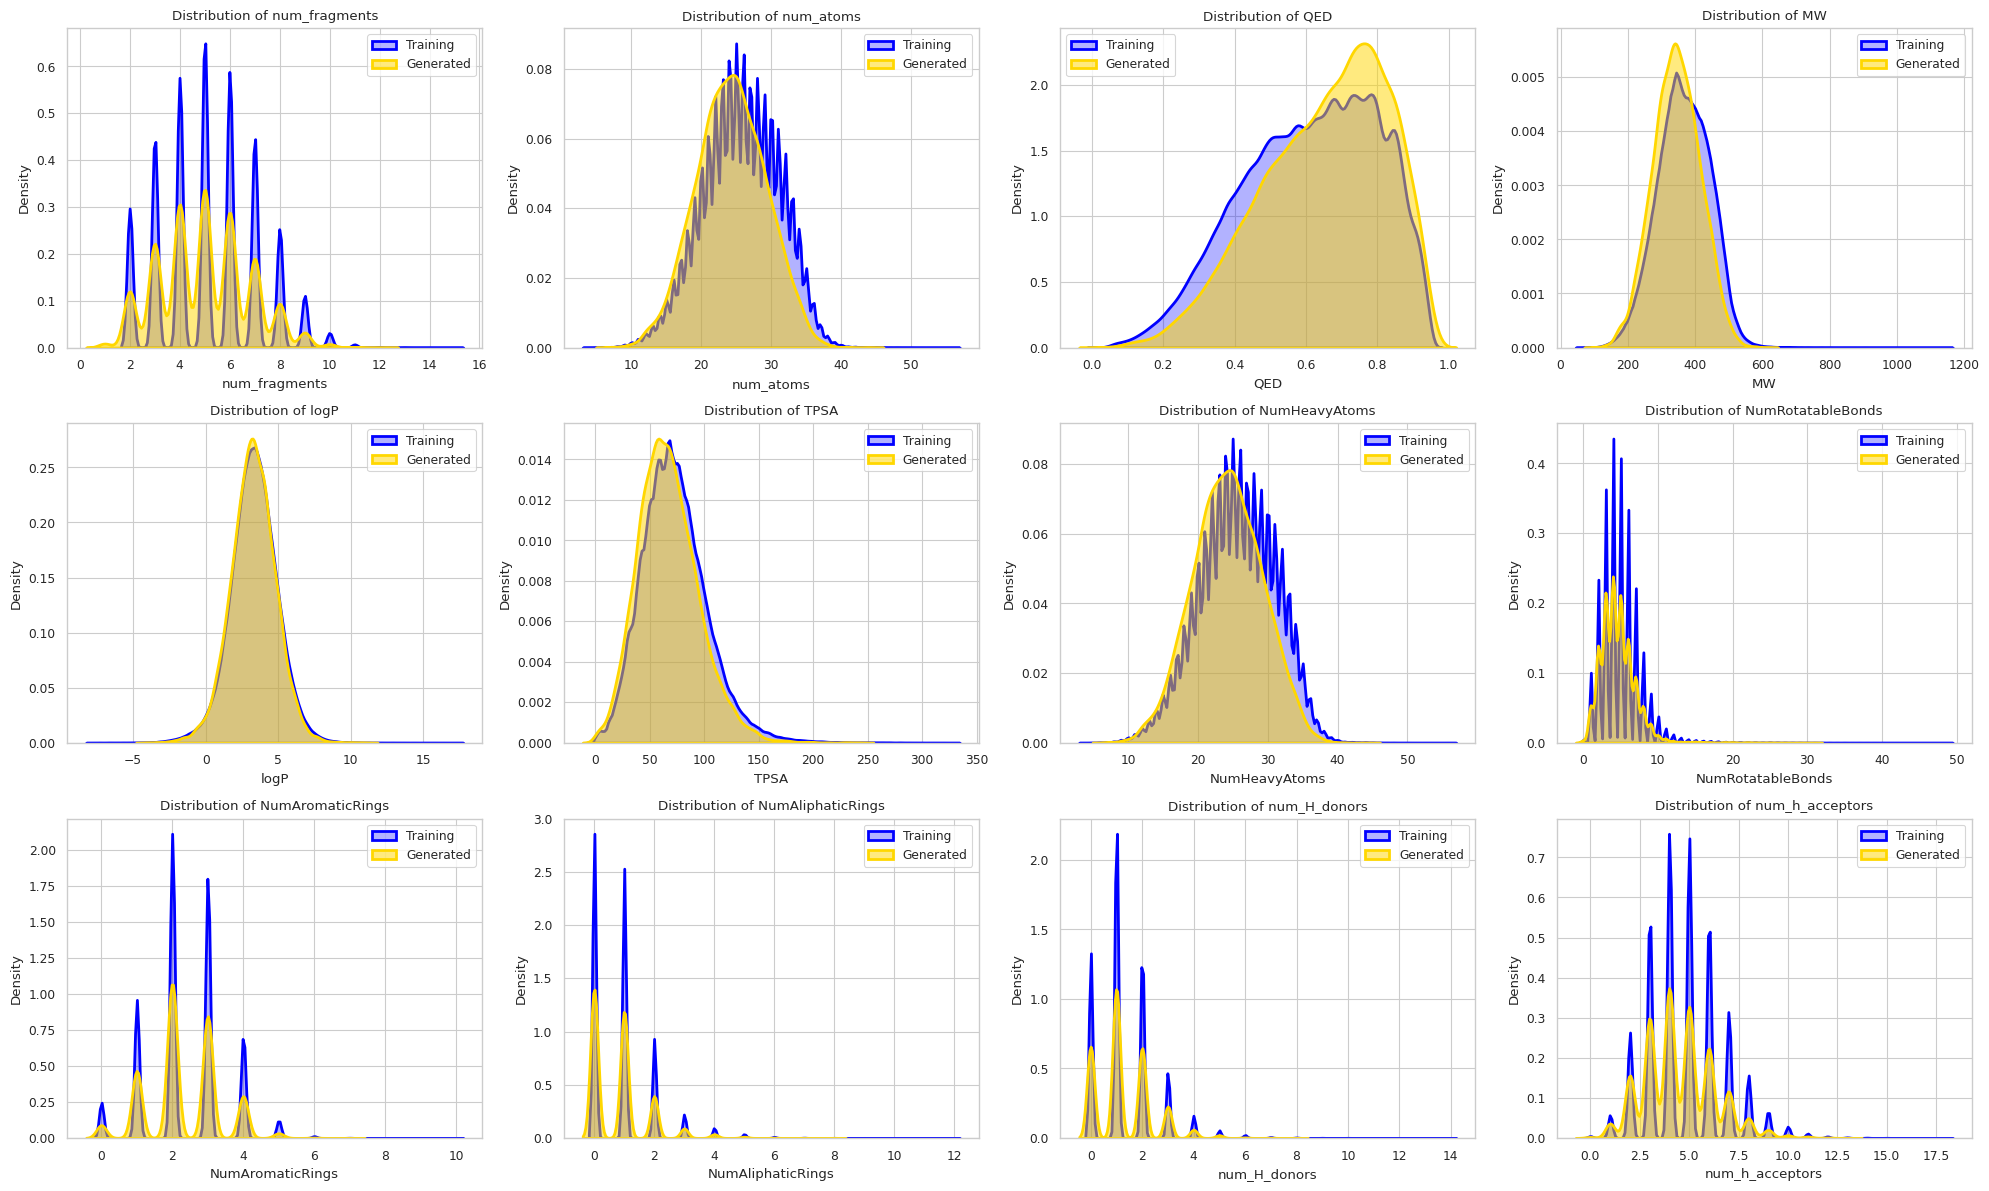

In [253]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of properties to compare
properties = [
    "num_fragments","num_atoms", "QED", "MW", "logP", "TPSA", "NumHeavyAtoms",
    "NumRotatableBonds", "NumAromaticRings", "NumAliphaticRings",
    "num_H_donors", "num_h_acceptors", 
]

# Set up the plot grid
n_cols = 4
n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()

# Plot each property in a subplot
for i, prop in enumerate(properties):
    ax = axes[i]

    # KDE plot for training set
    sns.kdeplot(df_main[prop].dropna(), fill=True, color='blue', label='Training',
                alpha=0.3, linewidth=2, ax=ax)

    # KDE plot for generated set
    sns.kdeplot(df_gen[prop].dropna(), fill=True, color='gold', label='Generated',
                alpha=0.5, linewidth=2, ax=ax)

    ax.set_title(f"Distribution of {prop}")
    ax.set_xlabel(prop)
    ax.set_ylabel("Density")
    ax.legend()

# Remove empty subplots if properties < n_rows * n_cols
for j in range(len(properties), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [282]:
s = df_gen[df_gen.QED>0.9]['smiles'].iloc[200]

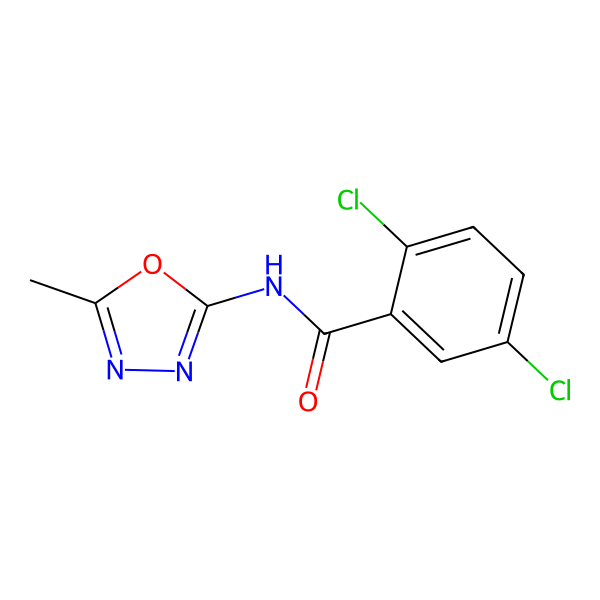

In [284]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D

mol = Chem.MolFromSmiles(s)

drawer = rdMolDraw2D.MolDraw2DSVG(600, 600)  # width, height in px
drawer.DrawMolecule(mol)
drawer.FinishDrawing()
svg = drawer.GetDrawingText()

# Save to file
with open("molecule5.png", "w") as f:
    f.write(svg)

# You can display SVG inline in Jupyter too:
from IPython.display import SVG, display
display(SVG(svg))

# Conditional Modeling

In [1]:
pwd

'/ictstr01/home/icb/ghaith.mqawass'

In [2]:
cd projs/morflow2.0/

/ictstr01/home/icb/ghaith.mqawass/projs/morflow2.0


In [4]:
import GPUtil
import torch
GPUs = GPUtil.getGPUs()
torch.cuda.empty_cache()
for gpu in GPUs:
    print(f"GPU id: {gpu.id}, name: {gpu.name}")
    print(f"  Memory Free: {gpu.memoryFree} MB")
    print(f"  Memory Used: {gpu.memoryUsed} MB")
    print(f"  Memory Total: {gpu.memoryTotal} MB")
    print(f"  GPU Load: {gpu.load*100}%")


GPU id: 0, name: NVIDIA A100-PCIE-40GB
  Memory Free: 38800.0 MB
  Memory Used: 1642.0 MB
  Memory Total: 40960.0 MB
  GPU Load: nan%


## Conditions 12 props with AdaptiveLN:

In [1]:
cd projs/morflow2.0/

/ictstr01/home/icb/ghaith.mqawass/projs/morflow2.0


In [3]:
import pandas as pd
from tqdm import tqdm
import numpy as np
import torch

In [6]:
df= pd.read_parquet('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/data/df_12_chem_props.parquet')

In [4]:
from modules.cond_lit_model import CondFlowMolBERTLitModule
from configs import *
from utils.metrics import compute_smiles_metrics,decode_tokens_to_smiles
from utils.sample import  cond_generate_mols
generator = torch.Generator().manual_seed(42)

/lustre/groups/ml01/workspace/ghaith.mqawass/flow/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
path = '/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/checkpoints/'
checkpoint_path = path + 'CFG-ChemProp_scaled_1.2M_canonical_training_set_adaptiveLN_uncond_prob=0.1_12_LR=0.0005_uniform_dim=768CFG_best_val_loss-epoch=46-cond_validity=0.8008.ckpt'
# checkpoint_path = '/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/checkpoints/CFG-ChemProp_1.2M_training_set_adaptiveLN_uncond_prob=0.1_12_LR=0.0001_uniform_dim=768CFG_best_val_loss-epoch=83-cond_validity=0.7480.ckpt'
# checkpoint_path = '/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/checkpoints/ChemProp_adaptiveLN_12_CrossEntropyLoss()_L=72_uniform_layers=12_dim=768fine_tuned_best_val_loss-epoch=52-cond_validity=0.4570.ckpt'
# checkpoint_path = '/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/checkpoints/last-v33.ckpt'
model = CondFlowMolBERTLitModule.load_from_checkpoint(checkpoint_path)
cfm = model.model
cfm.eval()

/lustre/groups/ml01/workspace/ghaith.mqawass/flow/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:209: Attribute 'loss_fn' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss_fn'])`.


CondFlowMolBERT(
  (tok_emb): Embedding(173, 767)
  (pos_emb): Embedding(72, 767)
  (time_emb): Linear(in_features=1, out_features=1, bias=True)
  (cond_proj): Sequential(
    (0): Linear(in_features=12, out_features=4096, bias=True)
    (1): ReLU()
    (2): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
    (3): Linear(in_features=4096, out_features=767, bias=True)
    (4): ReLU()
    (5): LayerNorm((767,), eps=1e-05, elementwise_affine=True)
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=767, out_features=767, bias=True)
  )
  (encoder): ConditionalTransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x ConditionalTransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (linear1): Linear(in_features=768, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=204

In [33]:
from torch.utils.data import DataLoader, random_split
from data import  CondMolDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = df[df["seq_len"] <= 72]
encoded = df["encoded"].apply(lambda x: x[:data.MAX_LEN]).tolist()
condition = df.iloc[:,-12:]  #conditions_are 12 chem_props
label = [True] * df.shape[0]
dataset = CondMolDataset(encoded,condition,label,df.index)
# train_val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size],generator = torch.Generator().manual_seed(42))
train_indices = train_dataset.indices
val_indices = val_dataset.indices
df_train = df.iloc[train_indices].copy()
df_val = df.iloc[val_indices].copy()

Converting SMILES to fingerprints: 0it [00:00, ?it/s]


In [37]:
len(df_val.iloc[:,-12:])

120128

In [38]:
conditions = df.iloc[:,-12:].to_numpy()
scaler = StandardScaler()
cond_scaled = scaler.fit_transform(conditions)
val_cond = scaler.transform(df_val.iloc[:,-12:].to_numpy())
cond_scaled = torch.tensor(cond_scaled, dtype = torch.float32)
val_cond_scaled = torch.tensor(val_cond, dtype = torch.float32)

In [40]:
val_cond_scaled[0]

tensor([ 0.9948,  0.4037,  0.7587,  0.7562, -0.0643,  0.9948,  0.7550, -0.3406,
         0.1523,  0.5953, -0.4273,  0.3457])

In [103]:
# conds = np.array(df_val.iloc[:,-13:-1])
# scaler = StandardScaler()
# cond_scaled = scaler.fit_transform(np.array(conds))
# conds_scaled = torch.tensor(cond_scaled, dtype = torch.float32)

In [41]:
avg_prop_vec = []
properties = [
    "num_atoms", "QED", "MW", "logP", "TPSA", "NumHeavyAtoms",
    "NumRotatableBonds", "NumAromaticRings", "NumAliphaticRings",
    "num_H_donors", "num_h_acceptors", "SA_score"
]
for prop in properties:
    avg_prop_vec.append(df[prop].mean())

In [172]:
# casted = np.array(avg_prop_vec)
# casted[0] = 35
# casted_scaled = scaler.transform(np.array(casted.reshape(1, -1)))
# casted_scaled = torch.tensor(casted_scaled, dtype = torch.float32)

In [89]:
df_val.iloc[:,-12:]

,num_atoms,QED,MW,logP,TPSA,NumHeavyAtoms,NumRotatableBonds,NumAromaticRings,NumAliphaticRings,num_H_donors,num_h_acceptors,SA_score
1456869,31,0.686241,423.557,4.53360,70.67,31,7,2,1,2,4,2.966297
403678,26,0.308855,354.414,0.20457,160.11,26,7,2,0,6,4,2.955632
117327,17,0.759233,293.168,2.94990,43.60,17,1,2,2,0,4,4.419729
346225,26,0.715159,352.350,1.29460,114.18,26,5,3,0,2,6,2.850975
337350,11,0.623852,157.213,0.83610,63.32,11,2,0,1,2,2,2.068342
...,...,...,...,...,...,...,...,...,...,...,...,...
1422802,25,0.458930,352.611,1.51810,0.00,25,8,0,6,0,0,4.967682
60209,36,0.345210,501.656,5.02810,84.49,36,6,4,2,3,6,3.119815
1266097,36,0.378829,530.456,5.19038,82.88,36,9,3,1,1,8,2.623368
767458,28,0.447893,490.341,4.73610,75.35,28,8,3,0,2,4,2.417711


In [99]:
gv = [25,0.9,350,1.3,114,25,5,2,0,2,6,2]
guiding_vector = torch.tensor(scaler.transform(np.array(gv).reshape(1, -1)), dtype = torch.float32)

In [101]:
guiding_vector

tensor([[-0.1186,  1.5520, -0.2004, -1.2329,  1.3679, -0.1186, -0.0053, -0.3406,
         -0.8725,  0.5953,  0.6581, -1.0628]])

In [102]:
from tqdm import tqdm 
import torch
device = 'cuda'
samples = cond_generate_mols(cfm,cond=guiding_vector,source_distribution='uniform',guidance_scale=1.5,num_samples=1000,steps=128, device = 'cuda', temperature=1.0)
_, target_smiles = decode_tokens_to_smiles(samples, ID2TOK=ID2TOK, TOK2ID=TOK2ID, PAD=PAD)
torch.cuda.empty_cache()

ValueError: Condition batch size must match num_samples or be broadcastable.

In [82]:
len(target_smiles)

722

In [83]:
target_vector = df_val.iloc[100,-12:].to_numpy()

In [80]:
df_val.iloc[:,-12:]

,num_atoms,QED,MW,logP,TPSA,NumHeavyAtoms,NumRotatableBonds,NumAromaticRings,NumAliphaticRings,num_H_donors,num_h_acceptors,SA_score
1456869,31,0.686241,423.557,4.53360,70.67,31,7,2,1,2,4,2.966297
403678,26,0.308855,354.414,0.20457,160.11,26,7,2,0,6,4,2.955632
117327,17,0.759233,293.168,2.94990,43.60,17,1,2,2,0,4,4.419729
346225,26,0.715159,352.350,1.29460,114.18,26,5,3,0,2,6,2.850975
337350,11,0.623852,157.213,0.83610,63.32,11,2,0,1,2,2,2.068342
...,...,...,...,...,...,...,...,...,...,...,...,...
1422802,25,0.458930,352.611,1.51810,0.00,25,8,0,6,0,0,4.967682
60209,36,0.345210,501.656,5.02810,84.49,36,6,4,2,3,6,3.119815
1266097,36,0.378829,530.456,5.19038,82.88,36,9,3,1,1,8,2.623368
767458,28,0.447893,490.341,4.73610,75.35,28,8,3,0,2,4,2.417711


In [77]:
target_vector

array([27, 0.655464218523973, 409.86000000000007, 5.604200000000003,
       43.09, 27, 2, 2, 2, 1, 3, 3.773570776065246], dtype=object)

In [84]:
import logging
from typing import List, Dict, Collection, Optional, Union
import numpy as np
from rdkit import Chem, RDLogger
from rdkit.Chem import QED, Descriptors
from rdkit.Chem import Lipinski
import pandas as pd
from tqdm import tqdm
import swifter
from rdkit.Chem.rdMolDescriptors import CalcNumAliphaticRings
from rdkit import Chem
from rdkit.Contrib.SA_Score import sascorer
# Mute RDKit logging
RDLogger.logger().setLevel(RDLogger.CRITICAL)

logger = logging.getLogger(__name__)
logger.addHandler(logging.NullHandler())


In [85]:
def get_mol(smiles_str: Collection[str]) -> List[Optional[Chem.Mol]]:

    if smiles_str is None:
        return None
    try:
        mol = Chem.MolFromSmiles(smiles_str)
    except Exception:
        mol = None
    return mol
def is_valid(smiles: str) -> bool:
    return Chem.MolFromSmiles(smiles) is not None

def is_sanitize_valid(mol: Chem.Mol) -> bool:
    if mol is None:
        return False
    try:
        Chem.SanitizeMol(mol)
        return True
    except:
        return False

In [86]:
def compute_properties_for_single(smiles: str) -> Dict[str, Union[float, bool]]:
    m = get_mol(smiles) # Get single mol
    return {
        "SMILES": smiles,
        "Valid": is_valid(smiles),
        "Sanitize": is_sanitize_valid(m),
        "num_atoms": m.GetNumAtoms() if m is not None else float('nan'),
        "QED": QED.qed(m) if m is not None else float('nan'),
        "MW": Descriptors.MolWt(m) if m is not None else float('nan'),
        "logP": Descriptors.MolLogP(m) if m is not None else float('nan'),
        "TPSA": Descriptors.TPSA(m) if m is not None else float('nan'),
        "NumHeavyAtoms": m.GetNumHeavyAtoms() if m is not None else float('nan'),
        "NumRotatableBonds": Descriptors.NumRotatableBonds(m) if m is not None else float('nan'),
        "NumAromaticRings": Descriptors.NumAromaticRings(m) if m is not None else float('nan'),
        "NumAliphaticRings": CalcNumAliphaticRings(m) if m is not None else float('nan'),
        "num_H_donors": Lipinski.NumHDonors(m) if m is not None else float('nan'),
        "num_h_acceptors": Lipinski.NumHAcceptors(m) if m is not None else float('nan'),
        "SA_score": sascorer.calculateScore(m) if m is not None else float('nan'),
    }

In [87]:
target_df_props = []
for smi in target_smiles:
    target_df_props.append(compute_properties_for_single(smi))
target_properties_df = pd.json_normalize(target_df_props)

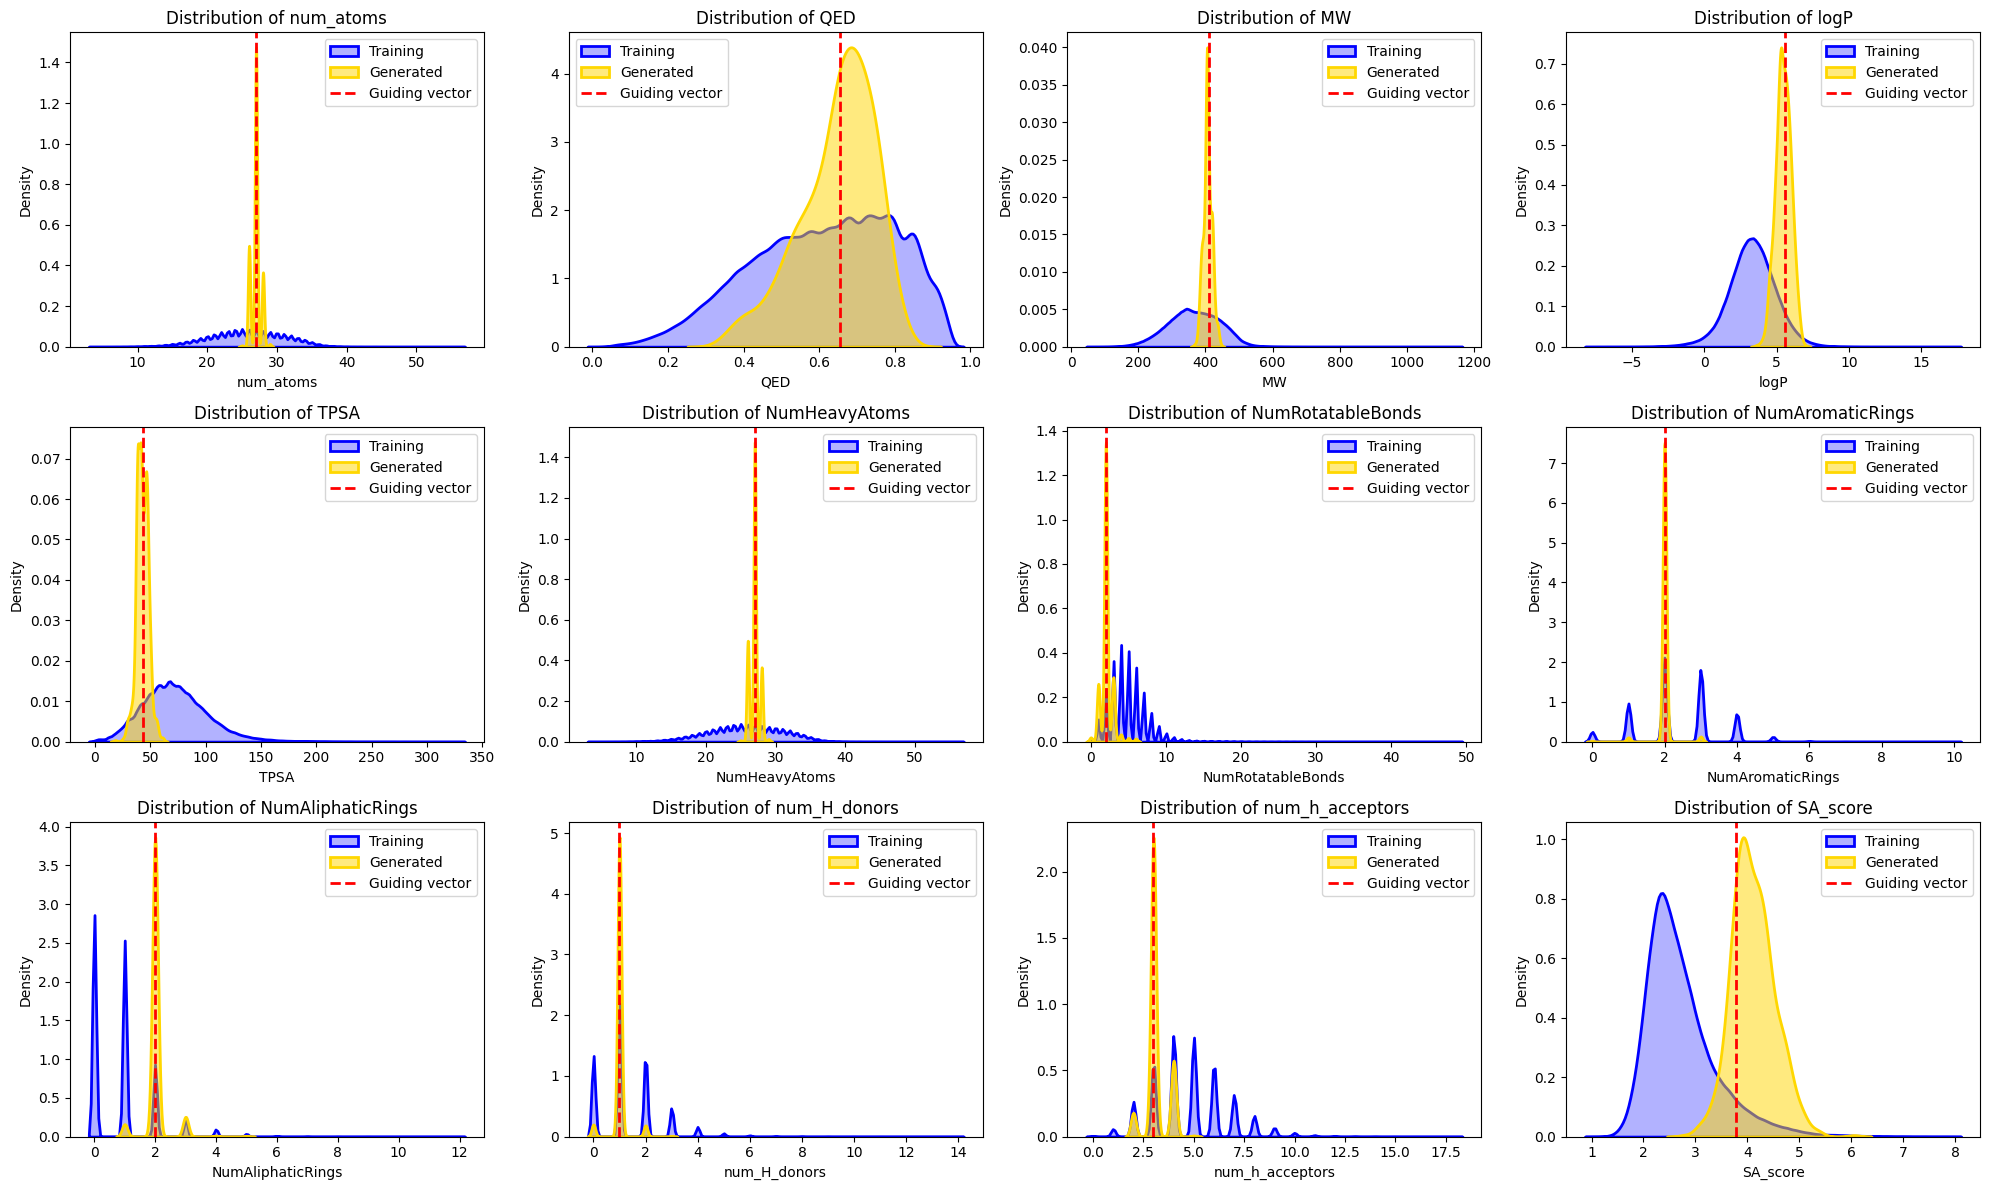

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of properties to compare
properties = [
    "num_atoms", "QED", "MW", "logP", "TPSA", "NumHeavyAtoms",
    "NumRotatableBonds", "NumAromaticRings", "NumAliphaticRings",
    "num_H_donors", "num_h_acceptors", 'SA_score'
]

# Set up the plot grid
n_cols = 4
n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()

# Plot each property in a subplot
for i, prop in enumerate(properties):
    ax = axes[i]

    # KDE plot for training set
    sns.kdeplot(df[prop].dropna(), fill=True, color='blue', label='Training',
                alpha=0.3, linewidth=2, ax=ax)
    
    #         # KDE plot for generated set
    # sns.kdeplot(avg_properties_df[prop].dropna(), fill=True, color='grey', label='Generated by avg cond',
    #             alpha=0.5, linewidth=2, ax=ax)

    # KDE plot for generated set
    sns.kdeplot(target_properties_df[prop].dropna(), fill=True, color='gold', label='Generated',
                alpha=0.5, linewidth=2, ax=ax)
    
    ax.axvline(target_vector[i], color='red', linestyle='--', linewidth=2, label='Guiding vector')
    


    ax.set_title(f"Distribution of {prop}")
    ax.set_xlabel(prop)
    ax.set_ylabel("Density")
    ax.legend()

# Remove empty subplots if properties < n_rows * n_cols
for j in range(len(properties), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("ChemProp1000samples_adaLN.png", dpi=300, bbox_inches="tight")
plt.show()

## Condition with ECFP3

In [71]:
import pandas as pd 
import numpy as np


In [ ]:
df = pd.read_parquet("data_path = '/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/data/df_12_chem_props.parquet")

In [33]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, RDKFingerprint
import numpy as np
from tqdm import tqdm
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator




def fast_smiles_to_fps(smiles_list, radius=3, fp_size=1024):
    # Ensure input is a list
    if isinstance(smiles_list, str):
        smiles_list = [smiles_list]

    # Initialize Morgan fingerprint generator
    morgan_gen = GetMorganGenerator(radius=radius, fpSize=fp_size)

    # Convert SMILES to molecules
    mols = [Chem.MolFromSmiles(smi) for smi in smiles_list]
    mols = [mol for mol in mols if mol is not None]  # filter invalid

    fps_np = []
    fps = []
    for mol in tqdm(mols, desc='Converting SMILES to fingerprints'):
        fp = morgan_gen.GetFingerprint(mol)
        fps.append(fp)
        arr = np.zeros((fp_size,), dtype=np.float32)
        DataStructs.ConvertToNumpyArray(fp, arr)
        fps_np.append(arr)

    return fps_np, fps # shape: (n_mols, fp_size)


# Set up generator once
morgan_gen1 = GetMorganGenerator(radius=3, fpSize=1024)
def compute_tanimoto_to_reference(smiles_list, reference_smiles):
    # Convert reference to fingerprint
    ref_mol = Chem.MolFromSmiles(reference_smiles)
    if ref_mol is None:
        raise ValueError("Invalid reference SMILES.")
    # ref_fp = RDKFingerprint(ref_mol)
    ref_fp = morgan_gen1.GetFingerprint(ref_mol)

    # Convert SMILES list to fingerprints
    _,fps_list = fast_smiles_to_fps(smiles_list,3,1024)

    # Compute similarity
    similarities = [
        DataStructs.TanimotoSimilarity(fp, ref_fp) for fp in fps_list
    ]
    return np.array(similarities)

In [46]:
from modules.cond_lit_model import CondFlowMolBERTLitModule
from configs import *
from utils.metrics import compute_smiles_metrics,decode_tokens_to_smiles
from utils.sample import  cond_generate_mols
generator = torch.Generator().manual_seed(42)

/lustre/groups/ml01/workspace/ghaith.mqawass/flow/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [47]:
checkpoint_path = '/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/checkpoints/last-v31.ckpt' #FP L1024 working
# checkpoint_path = '/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/checkpoints/MFP_adaptiveLN_proj_r3_L1024_2048_CrossEntropyLoss()_L=72_uniform_layers=12_dim=768fine_tuned_best_val_loss-epoch=55-cond_validity=0.4941.ckpt'
model = CondFlowMolBERTLitModule.load_from_checkpoint(checkpoint_path)
cfm = model.model
cfm.eval()

/lustre/groups/ml01/workspace/ghaith.mqawass/flow/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:209: Attribute 'loss_fn' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss_fn'])`.


CondFlowMolBERT(
  (tok_emb): Embedding(173, 767)
  (pos_emb): Embedding(72, 767)
  (time_emb): Linear(in_features=1, out_features=1, bias=True)
  (cond_proj): Sequential(
    (0): Linear(in_features=2048, out_features=4096, bias=True)
    (1): ReLU()
    (2): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
    (3): Linear(in_features=4096, out_features=767, bias=True)
    (4): ReLU()
    (5): LayerNorm((767,), eps=1e-05, elementwise_affine=True)
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=767, out_features=767, bias=True)
  )
  (encoder): ConditionalTransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x ConditionalTransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (linear1): Linear(in_features=768, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2

In [48]:
from torch.utils.data import DataLoader, random_split
from data import  CondMolDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = df[df["seq_len"] <= 72]
df = df.iloc[:100000,:]   #similar size to the perturbation data sizels -ls was [:99k,:]
df = df.reset_index(drop=True)  # to ensure 0-based indexing
df["original_index"] = df.index 
# df_conditioned = df[df['has_condition']==True]   #train with samples that have conditions only
encoded = df["encoded"].apply(lambda x: x[:data.MAX_LEN]).tolist()
condition = df.SMILES_standard  #conditions_are 11 chem_props
label = [True] * df.shape[0]
indices = df["original_index"].tolist()
# scaler = StandardScaler()
# cond_scaled = scaler.fit_transform(np.array(fast_smiles_to_fps(condition)[0]))
dataset = CondMolDataset(encoded,condition,label,indices)
# train_val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size],generator = torch.Generator().manual_seed(42))
train_indices = [item[3] for item in train_dataset]
val_indices = [item[3] for item in val_dataset]
df_train = df.loc[train_indices]
df_val = df.loc[val_indices]

Converting SMILES to fingerprints: 100%|██████████| 99000/99000 [00:09<00:00, 9949.90it/s] 


In [51]:
query_smiles = df_val.SMILES_standard[:100]
fps_np,_ = fast_smiles_to_fps(query_smiles,3,1024)
# cond_sc = scaler.transform(np.array(fps_np))
cond_sc = np.array(fps_np)
conds = torch.tensor(cond_sc, dtype = torch.float32)

Converting SMILES to fingerprints: 100%|██████████| 100/100 [00:00<00:00, 4807.67it/s]


In [52]:
query_smiles.iloc[0]

'COC(=O)C1=C(C)N(Cc2ccc(F)cc2)C(=S)NC1c1cccc(Cl)c1'

In [74]:
from tqdm import tqdm 
import torch
device = 'cuda'
SEED = 50
# sims = []
valid = []
means = []
# cond[3],8, 10,19 excellent for L1024 chekpoint v31
# for i in range(20):
samples = cond_generate_mols(cfm,cond=conds[0],source_distribution='uniform',guidance_scale=0.0,num_samples=100,steps=128, device = 'cuda', temperature=1.0)
_, smiles = decode_tokens_to_smiles(samples, ID2TOK=ID2TOK, TOK2ID=TOK2ID, PAD=PAD)
torch.cuda.empty_cache()
sims = compute_tanimoto_to_reference(smiles, query_smiles.iloc[0])
valid.append(len(smiles))
means.append(sims.mean())

NFE: 128: 100%|██████████| 0.9990000128746033/0.9990000128746033 [00:08<00:00,  8.84s/it]
Converting SMILES to fingerprints: 100%|██████████| 77/77 [00:00<00:00, 6665.32it/s]


In [78]:
sims

array([0.30526316, 0.51724138, 0.35051546, 0.47252747, 0.675     ,
       0.41052632, 0.43956044, 0.36633663, 0.40625   , 0.30392157,
       0.2952381 , 0.54117647, 0.39583333, 0.52325581, 0.37234043,
       0.30392157, 0.3814433 , 0.675     , 0.27777778, 0.27184466,
       0.40206186, 0.29411765, 0.29807692, 0.40625   , 0.59756098,
       0.675     , 0.45263158, 0.45555556, 0.27358491, 0.35051546,
       0.37234043, 0.49425287, 0.34653465, 0.40217391, 0.34375   ,
       0.57831325, 0.40217391, 0.40217391, 0.40625   , 0.31683168,
       0.50561798, 0.27358491, 0.70666667, 0.43617021, 0.5952381 ,
       0.44086022, 0.70666667, 0.30392157, 0.36633663, 0.35051546,
       0.46067416, 0.40217391, 0.3908046 , 0.71794872, 0.35106383,
       0.5952381 , 0.29126214, 0.40449438, 0.60493827, 0.40625   ,
       0.45555556, 0.34020619, 0.31      , 0.675     , 0.30392157,
       0.31578947, 0.31632653, 0.25      , 0.49425287, 0.36458333,
       0.46666667, 0.28431373, 0.39393939, 0.78082192, 0.38235

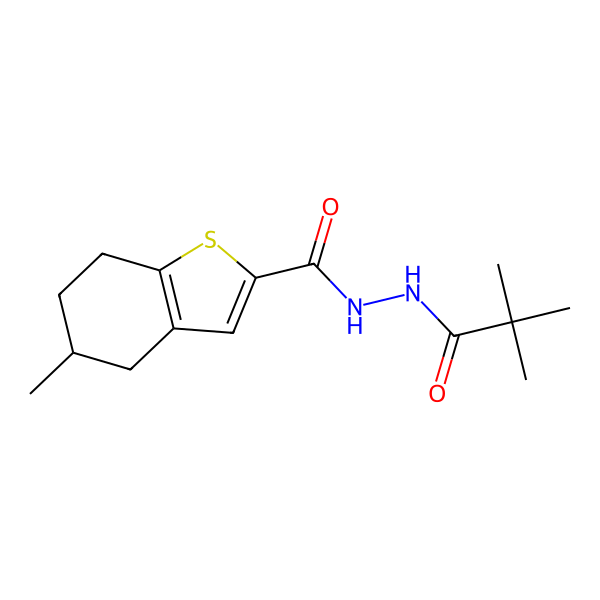

In [50]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
s = results.maxsim_canon.iloc[1]
mol = Chem.MolFromSmiles(s)

drawer = rdMolDraw2D.MolDraw2DSVG(600, 600)  # width, height in px
drawer.DrawMolecule(mol)
drawer.FinishDrawing()
svg = drawer.GetDrawingText()

# Save to file
drawer = rdMolDraw2D.MolDraw2DCairo(600, 600)
drawer.DrawMolecule(mol)
drawer.FinishDrawing()

with open("query.png", "wb") as f:
    f.write(drawer.GetDrawingText())

# You can display SVG inline in Jupyter too:
from IPython.display import SVG, display
display(SVG(svg))

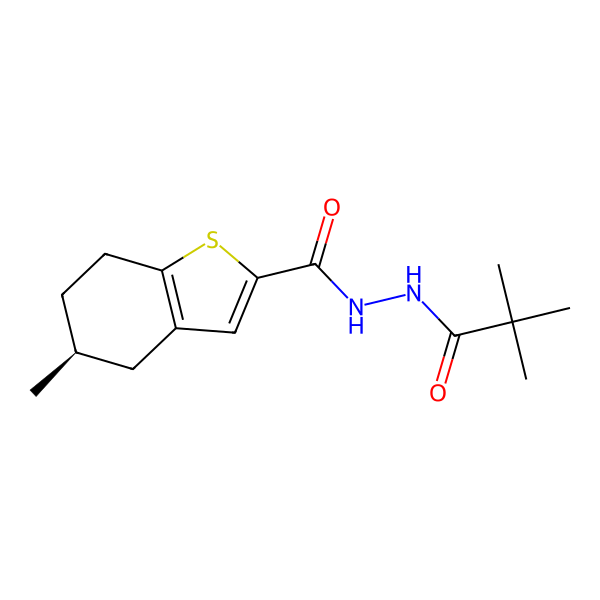

In [51]:
s = results.query_canon[1]
mol = Chem.MolFromSmiles(s)
drawer = rdMolDraw2D.MolDraw2DSVG(600, 600)  # width, height in px
drawer.DrawMolecule(mol)
drawer.FinishDrawing()
svg = drawer.GetDrawingText()

# Save to file
drawer = rdMolDraw2D.MolDraw2DCairo(600, 600)
drawer.DrawMolecule(mol)
drawer.FinishDrawing()

with open("generated445.png", "wb") as f:
    f.write(drawer.GetDrawingText())

# You can display SVG inline in Jupyter too:
from IPython.display import SVG, display
display(SVG(svg))

### Condition on unseen samples from zinc250k 

In [1]:
pwd

'/ictstr01/home/icb/ghaith.mqawass'

In [2]:
cd projs/morflow2.0

/ictstr01/home/icb/ghaith.mqawass/projs/morflow2.0


In [3]:
import pandas as pd
from rdkit import Chem
import pandas as pd

allowed_atoms = {'C', 'O', 'P', 'N', 'S', 'Cl', 'F', 'H'}

def is_allowed_smiles(smiles, allowed=allowed_atoms):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False  # skip invalid SMILES
    
    # Extract all atom symbols
    atoms = {atom.GetSymbol() for atom in mol.GetAtoms()}
    
    # Keep only if all atoms are in the allowed set
    return atoms.issubset(allowed)

In [41]:
import pandas as pd
import numpy as np
dfs = [results, results2, results3]

for df in dfs:
    df['Validity']= df['validity']/100
    df['Top1_Tanimoto'] = df['top1_tanimoto'] 
    df['Top10_Tanimoto'] = df['top10_tanimoto'] 
metrics = ['Top1_Tanimoto', 'Top10_Tanimoto', 'Validity']

# Compute per-seed means
per_seed_means = pd.DataFrame({metric: [df[metric].mean() for df in dfs] for metric in metrics})

# Compute overall mean ± std across seeds
summary = per_seed_means.agg(['mean', 'std']).T.reset_index()
summary.columns = ['Metric', 'Mean', 'Std']

print(summary)



           Metric      Mean       Std
0   Top1_Tanimoto  0.766569  0.008817
1  Top10_Tanimoto  0.703023  0.006553
2        Validity  0.903867  0.000700


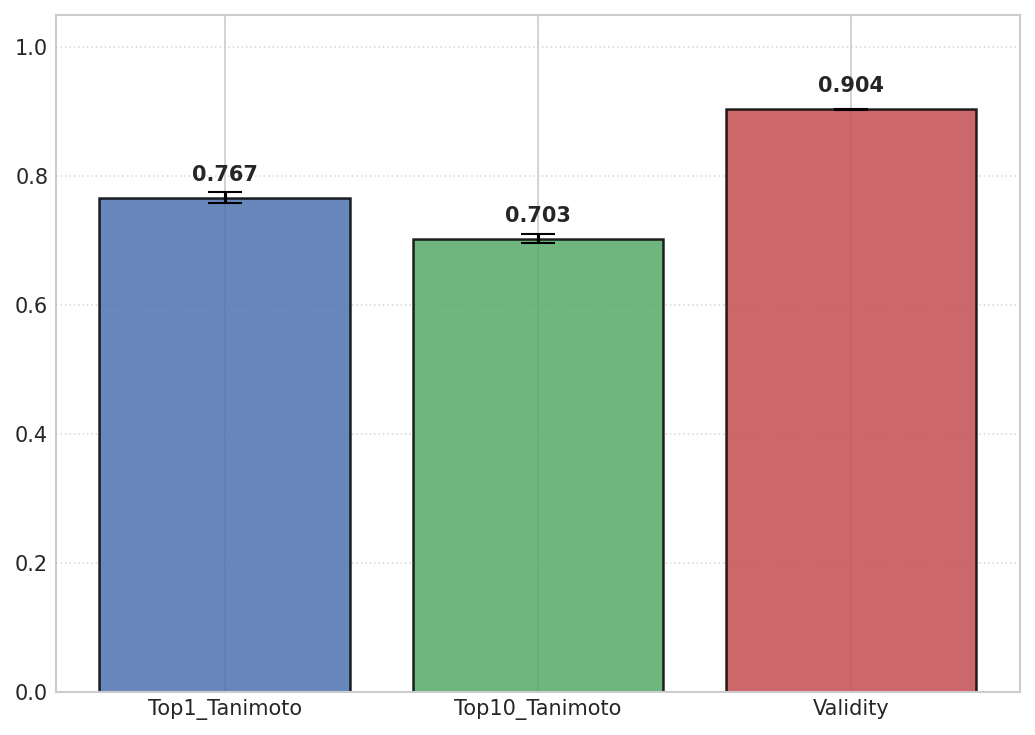

In [46]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')  # clean academic style
fig, ax = plt.subplots(figsize=(7,5), dpi=150)

# Bar plot with fancy colors
colors = ['#4C72B0', '#55A868', '#C44E52']
bars = ax.bar(summary['Metric'], summary['Mean'], yerr=summary['Std'],
              color=colors, alpha=0.85, capsize=8, edgecolor='black', linewidth=1.2)

# # Add markers for mean points
# for i, row in summary.iterrows():
#     ax.plot(i, row['Mean'], marker='o', markersize=10, color='gold', markeredgecolor='black')
# for i, row in summary.iterrows():
#     ax.hlines(y=row['Mean'], xmin=i - 0.25, xmax=i + 0.25, colors='black', linestyles='dashed', linewidth=1.5)
# Annotate mean values on top of bars
for bar, mean in zip(bars, summary['Mean']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Axis labels and limits
# ax.set_ylabel("Metric Value", fontsize=12)
# ax.set_title("Model Performance Across Metrics", fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)

# # Remove top and right spines for cleaner academic look
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# Grid and ticks
ax.yaxis.grid(True, linestyle=':', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('3random_seeds_avg.png')
plt.show()

In [29]:
print(plt.style.available)


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [38]:
# results = pd.read_csv('results/FP/zinc_test/cfg0.1_test_conditional_generation_tanimoto_results_1024.csv')
import pandas as pd
results = pd.read_csv('results/FP/zinc_test/cfg0.1_test_conditional_generation_canonical_results_1024_1k_samples_seed17.csv')
results2 = pd.read_csv('results/FP/zinc_test/cfg0.1_test_conditional_generation_canonical_results_1024_1k_samples_seed50.csv')
results3 = pd.read_csv('results/FP/zinc_test/cfg0.1_test_conditional_generation_canonical_results_1024_1k_samples_seed420.csv')

In [47]:
results['top1_tanimoto'].mean() , results2['top1_tanimoto'].mean(),  results3['top1_tanimoto'].mean()

(np.float64(0.7565981481496555),
 np.float64(0.7697715012296845),
 np.float64(0.7733372907893861))

In [48]:
results['top1_tanimoto'].std() , results2['top1_tanimoto'].std(),  results3['top1_tanimoto'].std()

(0.2573153280022977, 0.24291955781576216, 0.24490950514007742)

In [7]:
results[results['smiles_match']==1]

,query_smiles,mean_tanimoto,top1_tanimoto,top5_tanimoto,top10_tanimoto,mean_maccs,top1_maccs,top5_maccs,top10_maccs,mean_mcs,top1_mcs,top5_mcs,top10_mcs,validity,uniqueness,maxsim_smiles,smiles_match
4,O=C(Nc1ccc(F)cc1)N1CCC(Cn2cnc3ccccc32)CC1,0.982000,1.0,1.000000,1.000000,0.996400,1.0,1.000000,1.000000,0.948077,1.0,1.000000,1.000000,100,2,O=C(Nc1ccc(F)cc1)N1CCC(Cn2cnc3ccccc32)CC1,1
7,O=C(Nc1nc2cc(C(F)(F)F)ccc2n1Cc1ccco1)C1CC=CCC1,0.483162,1.0,0.911340,0.734021,0.820536,1.0,0.989286,0.967857,0.602814,1.0,0.992857,0.978571,99,17,O=C(Nc1nc2cc(C(F)(F)F)ccc2n1Cc1ccco1)C1CC=CCC1,1
11,CCc1onc(C)c1NC(=O)C1CC1c1cccc2ccccc12,0.558114,1.0,0.792593,0.723457,0.929313,1.0,0.975510,0.967347,0.777917,1.0,1.000000,1.000000,100,7,CCc1onc(C)c1NC(=O)C1CC1c1cccc2ccccc12,1
13,COCC(C)n1c(C)cc(C(=O)CN2C(=O)NC3(CCCc4ccccc43)...,0.980356,1.0,1.000000,1.000000,0.996358,1.0,1.000000,1.000000,0.998065,1.0,1.000000,1.000000,100,4,COCC(C)n1c(C)cc(C(=O)CN2C(=O)NC3(CCCc4ccccc43)...,1
14,CC(C)=CC(=O)NCc1ccc(C(=O)N(c2ccccc2)C(C)C)cc1,0.481707,1.0,1.000000,0.881356,0.830122,1.0,1.000000,1.000000,0.687870,1.0,1.000000,0.965385,78,48,CC(C)=CC(=O)NCc1ccc(C(=O)N(c2ccccc2)C(C)C)cc1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,Cc1ccccc1OCC(=O)NC1CC(C)N(c2ccccc2)C1,0.581571,1.0,1.000000,1.000000,0.876319,1.0,1.000000,1.000000,0.665825,1.0,1.000000,1.000000,99,41,Cc1ccccc1OCC(=O)NC1CC(C)N(c2ccccc2)C1,1
989,CCn1nc(C)c(NC(=O)Nc2cccc(COC(C)C)c2)c1C,0.592398,1.0,1.000000,0.885714,0.876224,1.0,1.000000,0.972204,0.814474,1.0,1.000000,0.991667,95,29,CCn1nc(C)c(NC(=O)Nc2cccc(COC(C)C)c2)c1C,1
990,O=C(CCl)NNC(=O)c1cccc(S(=O)(=O)N2CCOCC2)c1,0.994796,1.0,1.000000,1.000000,0.998293,1.0,1.000000,1.000000,0.999122,1.0,1.000000,1.000000,99,2,O=C(CCl)NNC(=O)c1cccc(S(=O)(=O)N2CCOCC2)c1,1
996,COc1ccc(C)cc1NC(=O)C(=O)NN=Cc1ccccc1F,0.580224,1.0,1.000000,1.000000,0.939485,1.0,1.000000,1.000000,0.730000,1.0,1.000000,1.000000,100,10,COc1ccc(C)cc1NC(=O)C(=O)NN=Cc1ccccc1F,1


In [103]:
import pandas as pd
df_test = pd.read_parquet( "/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/data/ms_data/fingerprints_from_pretrained_encoder/canopus/canopus_val_safe_encoded.parquet") #chembl but its zinc actually, wrong naming

In [102]:
df_test

,smiles,inchi,fingerprint
0,CCOC(=O)CCC(C)C1CCC2C3C(O)CC4CC(=O)CCC4(C)C3CC...,SXNROIKPQUADKR-UHFFFAOYSA-N,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ..."
1,CCCCC=CCCCCCc1cc(=O)c2ccccc2n1C,ILAQTUNYLVMXNW-UHFFFAOYSA-N,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,CC=CC(=O)N(CC)C(CC)C(=O)N(C)C,LSAMUAYPDHUBQD-UHFFFAOYSA-N,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,COc1c2c(nc3occc13)C(CC=C(C)C)(OC)C(O)CC2,RNZIQNGNLJSLHV-UHFFFAOYSA-N,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,CC(C)(COP(=O)(O)OP(=O)(O)OCC1OC(n2cnc3c(N)ncnc...,VEVJTUNLALKRNO-UHFFFAOYSA-N,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...
391,Clc1ncoc1-c1c[nH]c2ccccc12,BKYJGKRXUHPPLR-UHFFFAOYSA-N,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
392,Cc1ncc([N+](=O)[O-])n1CC(C)O,KPQZUUQMTUIKBP-UHFFFAOYSA-N,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
393,O=C1NC(Cc2ccccc2)CN2CCCCC12,CUANCTHYEDWUMU-UHFFFAOYSA-N,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
394,C#CCN(C(C)=O)C(C)Cc1ccccc1,JJOSIKPABYYKOP-UHFFFAOYSA-N,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [95]:
df_test.top1_tanimoto.mean()

np.float64(0.35958375290744743)

In [5]:
df_test = df_test[df_test.seq_len<=72]

In [15]:
# Canonicalize both columns
# results["query_canon"] = results["query_smiles"].apply(canonicalize)
# results["maxsim_canon"] = results["maxsim_smiles"].apply(canonicalize)

# Binary match (1 if equal, 0 otherwise)
results["smiles_match"] = (results["query_smiles"] == results["maxsim_smiles"]).astype(int)

In [16]:
len(results[results["smiles_match"]==1])

480

In [12]:
results['top1_tanimoto'].mean(), results['top1_tanimoto'].std() ,results['top10_tanimoto'].mean(), results['top10_tanimoto'].std() , results['validity'].mean() , results['validity'].std()

(np.float64(0.7697715012296845),
 0.24291955781576216,
 np.float64(0.7072740671065362),
 0.2532973336656389,
 np.float64(90.431),
 15.107729229850644)

In [15]:
results['top1_tanimoto'].mean(), results['top1_tanimoto'].std() ,results['top10_tanimoto'].mean(), results['top10_tanimoto'].std() , results['validity'].mean() , results['validity'].std()

(0.7733372907893861,
 0.24490950514007742,
 0.706319649046837,
 0.2527053619187669,
 90.423,
 14.41443189469655)

In [62]:
df_sampled = df_test.sample(n=100, random_state=42)
query_smiles = df_sampled.smiles
# query_smiles = df[df['top1_tanimoto']==1]['query_smiles']
fps_np,_ = fast_smiles_to_fps(query_smiles,3,1024)
# cond_sc = scaler.transform(np.array(fps_np))
cond_sc = np.array(fps_np)
conds = torch.tensor(cond_sc, dtype = torch.float32)

Converting SMILES to fingerprints: 100%|██████████| 100/100 [00:00<00:00, 13391.35it/s]


In [6]:
from modules.cond_lit_model import CondFlowMolBERTLitModule
from configs import *
from utils.metrics import compute_smiles_metrics,decode_tokens_to_smiles
from utils.sample import  cond_generate_mols
generator = torch.Generator().manual_seed(42)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

/lustre/groups/ml01/workspace/ghaith.mqawass/flow/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
checkpoint_path = 'CFG-ChemProp_1.2M_training_set_adaptiveLN_uncond_prob=0.1_12_LR=0.0001_uniform_dim=768CFG_best_val_loss-epoch=30-cond_validity=0.6963.ckpt' #last-v31.ckpt #FP L1024 working
model = CondFlowMolBERTLitModule.load_from_checkpoint(checkpoint_path)
cfm = model.model
cfm.eval()

/lustre/groups/ml01/workspace/ghaith.mqawass/flow/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:209: Attribute 'loss_fn' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss_fn'])`.


CondFlowMolBERT(
  (tok_emb): Embedding(173, 767)
  (pos_emb): Embedding(72, 767)
  (time_emb): Linear(in_features=1, out_features=1, bias=True)
  (cond_proj): Sequential(
    (0): Linear(in_features=1024, out_features=4096, bias=True)
    (1): ReLU()
    (2): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
    (3): Linear(in_features=4096, out_features=767, bias=True)
    (4): ReLU()
    (5): LayerNorm((767,), eps=1e-05, elementwise_affine=True)
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=767, out_features=767, bias=True)
  )
  (encoder): ConditionalTransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x ConditionalTransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (linear1): Linear(in_features=768, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2

In [92]:
from tqdm import tqdm 
import torch
device = 'cuda'
# sims = []
valid = []
means = []
top1_smiles = []
# for i in range(20):
samples = cond_generate_mols(cfm,cond=conds[51],source_distribution='uniform',guidance_scale=1.5, num_samples=100,steps=128, device = 'cuda', temperature=1)
_, smiles = decode_tokens_to_smiles(samples, ID2TOK=ID2TOK, TOK2ID=TOK2ID, PAD=PAD)
torch.cuda.empty_cache()
sims = compute_tanimoto_to_reference(smiles, query_smiles.iloc[51])
valid.append(len(smiles))
means.append(sims.mean())
top1_smiles.append(smiles[sims.argmax()])

NFE: 0:   0%|          | 0/0.9990000128746033 [00:00<?, ?it/s]

NFE: 128: 100%|██████████| 0.9990000128746033/0.9990000128746033 [00:16<00:00, 16.92s/it]
Converting SMILES to fingerprints: 100%|██████████| 97/97 [00:00<00:00, 14489.90it/s]


In [93]:
np.array(means).mean(),np.array(means).std() ,np.array(valid).mean(), np.array(valid).std()

(0.9360782303459277, 0.0, 97.0, 0.0)

In [94]:
means

[0.9360782303459277]

In [95]:
sims.max()

1.0

In [96]:
sims.argmax()

1

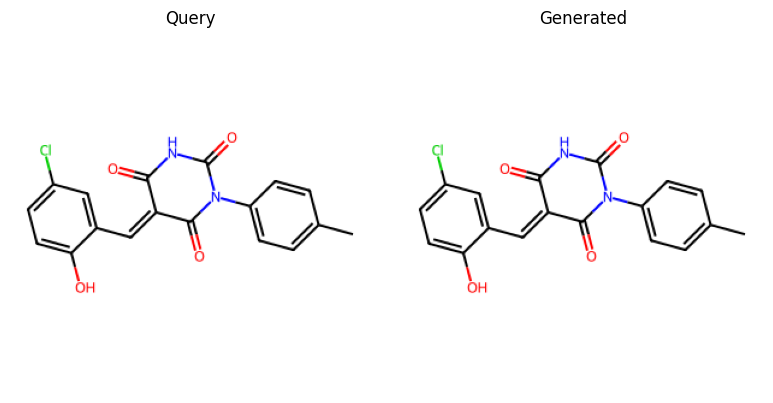

In [98]:
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

# Example SMILES
query_s = query_smiles.iloc[51]
gen_s = smiles[1]

# Convert to RDKit molecules
mol_query = Chem.MolFromSmiles(query_s)
mol_gen = Chem.MolFromSmiles(gen_s)

# Draw molecules as images (PIL)
img_query = Draw.MolToImage(mol_query, size=(300, 300))
img_gen = Draw.MolToImage(mol_gen, size=(300, 300))

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(img_query)
axes[0].set_title("Query")
axes[0].axis("off")

axes[1].imshow(img_gen)
axes[1].set_title("Generated")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("query_generated_unseen.png")
plt.show()


## CP conditions

In [1]:
pwd

'/ictstr01/home/icb/ghaith.mqawass'

In [2]:
cd projs/morflow2.0/

/ictstr01/home/icb/ghaith.mqawass/projs/morflow2.0


In [9]:
import pandas as pd
import numpy as np
from modules.cond_lit_model import CondFlowMolBERTLitModule
from configs import *
from utils.metrics import compute_smiles_metrics,decode_tokens_to_smiles
from utils.sample import  cond_generate_mols

/lustre/groups/ml01/workspace/ghaith.mqawass/flow/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df = pd.read_parquet("/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/data/df_main_wconditions.parquet")

In [5]:
df[df.has_condition==True].iloc[:,-1450:-1]

,Cells_AreaShape_Area,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_AreaShape_Compactness,Cells_AreaShape_Eccentricity,Cells_AreaShape_Extent,Cells_AreaShape_FormFactor,Cells_AreaShape_MajorAxisLength,Cells_AreaShape_MaxFeretDiameter,Cells_AreaShape_MaximumRadius,...,Nuclei_Texture_Variance_DNA_5_0,Nuclei_Texture_Variance_ER_10_0,Nuclei_Texture_Variance_ER_3_0,Nuclei_Texture_Variance_ER_5_0,Nuclei_Texture_Variance_Mito_10_0,Nuclei_Texture_Variance_Mito_3_0,Nuclei_Texture_Variance_Mito_5_0,Nuclei_Texture_Variance_RNA_10_0,Nuclei_Texture_Variance_RNA_3_0,Nuclei_Texture_Variance_RNA_5_0
41,-0.233248,2.314919,0.746245,0.790115,-0.014804,-2.220936,0.015262,-0.282345,-0.310876,-0.926161,...,-0.531103,-1.975379,-1.537216,-1.694384,-2.010195,-1.523325,-1.923111,-0.721703,-0.715398,-0.727716
42,0.113236,-0.777379,0.149887,2.828240,2.061217,-2.516237,-0.103453,0.728947,0.757317,-0.692783,...,-1.733040,-1.541783,-1.810282,-1.424348,-2.175736,-3.025378,-2.738477,-0.819643,-0.848581,-0.999255
43,0.145744,1.287664,0.146628,0.995885,1.502253,-0.916408,-0.380869,0.500023,0.554712,-0.798817,...,1.475110,2.077431,1.447079,1.966638,-0.810950,-1.186248,-0.916034,0.138561,0.185454,0.275543
44,1.765294,0.621796,0.337245,0.130425,0.323302,-0.552423,-1.016340,1.149204,1.183307,2.179151,...,1.034525,-0.544909,-0.861115,-1.197857,-0.804342,-0.327998,-0.195914,-1.334798,-1.339023,-1.545277
103,-0.355981,0.032902,0.858443,-0.996262,-1.051054,0.485349,0.572209,-0.888975,-0.802617,-0.155826,...,-0.366345,-0.257138,0.040612,0.642153,1.675547,1.192460,1.617220,0.153353,-0.475143,-0.231460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1569903,-0.845165,-0.044966,0.049962,2.003443,1.462058,-2.275085,1.534041,-0.090299,-0.136641,-0.914476,...,0.136318,-0.797883,-0.593471,-0.493009,-1.244405,-2.110788,-1.836207,-1.274073,-2.301869,-1.711431
1570027,-1.762612,-0.773197,0.030659,0.041698,0.520923,0.615781,-0.224689,-1.836850,-1.662979,-1.473157,...,-0.806789,-0.457203,-0.602982,-0.547415,0.718081,0.439811,0.590267,-0.874343,-0.684231,-0.800881
1570028,-0.418355,-0.733509,0.846420,0.543788,0.525275,0.361519,1.308120,0.009190,-0.258397,-0.416540,...,5.528739,2.295507,2.995736,2.664799,2.127725,1.240653,2.348788,1.051124,0.903840,1.239163
1570029,-3.191893,-0.483217,-0.301368,-0.085434,0.466976,0.764928,0.660188,-2.544781,-3.071886,-3.545717,...,2.301855,1.984188,1.634704,1.497178,2.264390,1.183333,1.384463,2.857784,2.155025,3.448053


In [18]:
from torch.utils.data import DataLoader, random_split
from data import  CondMolDataset
from sklearn.preprocessing import StandardScaler

df = df[df["seq_len"] <= 72]
df = df.reset_index(drop=True)  # to ensure 0-based indexing
generator = torch.Generator().manual_seed(42)
df_conditioned = df[df['has_condition']==True]   #train with samples that have conditions only
encoded = df_conditioned["encoded"].apply(lambda x: x[:data.MAX_LEN]).tolist()
condition = df_conditioned.iloc[:,-1450:-1]#[:,-1451:-2]  #conditions_are 11 chem_props
label = [True] * df.shape[0]
dataset = CondMolDataset(encoded,condition,label,df_conditioned.index)
# train_val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size],generator=generator)
train_indices = [item[3] for item in train_dataset]
val_indices = [item[3] for item in val_dataset]
df_train = df.loc[train_indices]
df_val = df.loc[val_indices]

In [19]:
from modules.cond_lit_model import CondFlowMolBERTLitModule
from configs import *
from utils.metrics import compute_smiles_metrics,decode_tokens_to_smiles
from utils.sample import  cond_generate_mols

In [20]:
checkpoint_path = '/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/checkpoints/CP_adaptiveLN_1449_CrossEntropyLoss()_L=72_uniform_layers=12_dim=768fine_tuned_best_val_loss-epoch=52-cond_validity=0.5771.ckpt' #last-v37.ckpt for 12 props trained on 15th Sept
model = CondFlowMolBERTLitModule.load_from_checkpoint(checkpoint_path)
cfm = model.model
cfm.eval()

/lustre/groups/ml01/workspace/ghaith.mqawass/flow/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:209: Attribute 'loss_fn' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss_fn'])`.


CondFlowMolBERT(
  (tok_emb): Embedding(173, 767)
  (pos_emb): Embedding(72, 767)
  (time_emb): Linear(in_features=1, out_features=1, bias=True)
  (cond_proj): Sequential(
    (0): Linear(in_features=1449, out_features=4096, bias=True)
    (1): ReLU()
    (2): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
    (3): Linear(in_features=4096, out_features=767, bias=True)
    (4): ReLU()
    (5): LayerNorm((767,), eps=1e-05, elementwise_affine=True)
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=767, out_features=767, bias=True)
  )
  (encoder): ConditionalTransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x ConditionalTransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (linear1): Linear(in_features=768, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2

In [28]:
cp_conditions = np.array(df_val.iloc[:,-1450:-1])

,Cells_AreaShape_Area,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_AreaShape_Compactness,Cells_AreaShape_Eccentricity,Cells_AreaShape_Extent,Cells_AreaShape_FormFactor,Cells_AreaShape_MajorAxisLength,Cells_AreaShape_MaxFeretDiameter,Cells_AreaShape_MaximumRadius,...,Nuclei_Texture_Variance_DNA_5_0,Nuclei_Texture_Variance_ER_10_0,Nuclei_Texture_Variance_ER_3_0,Nuclei_Texture_Variance_ER_5_0,Nuclei_Texture_Variance_Mito_10_0,Nuclei_Texture_Variance_Mito_3_0,Nuclei_Texture_Variance_Mito_5_0,Nuclei_Texture_Variance_RNA_10_0,Nuclei_Texture_Variance_RNA_3_0,Nuclei_Texture_Variance_RNA_5_0
863232,1.207742,0.529957,2.555965,1.740522,2.126886,-2.387224,1.209305,1.178194,1.133025,0.800383,...,2.200260,-1.300648,-0.881374,-1.262251,-0.840859,-0.424727,-0.566094,2.102893,1.628251,2.043710
1272124,-1.738111,-0.433601,0.053959,-0.594116,-0.692890,1.337558,-0.009389,-1.669626,-1.835990,-1.391058,...,-0.749947,-0.505889,-0.738106,-0.486647,-0.261374,-0.420510,-0.185041,-0.638863,-0.815382,-0.398239
1141692,1.377905,-2.895659,-0.195247,1.382321,0.425196,-1.263524,0.784260,1.633443,2.181934,1.389990,...,-0.955143,0.937691,-0.516824,-0.323484,-0.020918,-0.407062,0.177299,-0.431431,-0.538740,-0.566299
514103,-0.744646,1.328542,-0.674491,-0.194394,-0.033058,-0.413106,2.003477,-0.997261,-0.964466,-1.080146,...,-0.889486,0.110906,-0.540050,-0.477437,-0.797019,-0.408270,-0.533595,-0.829053,-0.663906,-0.823813
1230919,-1.511790,-0.936028,0.760335,-0.683069,-0.823424,0.730571,1.355647,-1.556490,-1.998647,-0.857322,...,0.364828,1.484046,2.047382,1.854142,0.747813,-0.142600,0.178062,0.515349,0.937581,0.789174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493897,9.266669,-0.149887,-0.864191,7.374832,4.268406,-5.155771,-2.614473,8.202298,8.233935,7.374386,...,0.002031,-0.872946,-1.221489,-1.074173,-1.689781,-2.203091,-2.166709,-0.522582,-2.802432,-2.485301
523916,-0.919251,-0.674491,0.883815,-0.175600,-0.139691,-0.191258,-1.755600,-0.663478,-0.569618,-1.116064,...,-2.593442,-0.853943,-1.563814,-1.546719,-0.796247,-1.017579,-0.843092,-1.274937,-1.568963,-1.576974
472131,-1.085426,-1.299928,2.922793,0.306586,-0.004802,-0.689976,2.502446,-0.626738,-0.805893,-1.421579,...,-0.738681,-0.437234,-1.463396,-1.291163,-1.269456,-1.472222,-1.199281,-1.548595,-1.730722,-1.864599
37747,0.548511,-0.224830,-0.056208,1.852394,1.957709,-0.250553,0.471645,0.775888,0.740563,0.168833,...,0.601931,1.282298,0.381802,0.581235,-1.768019,-1.329626,-1.710020,-0.157161,-0.825473,-1.041855


In [34]:
train_cp_conditions = np.array(df_train.iloc[:,-1450:-1])
val_cp_conditions = np.array(df_val.iloc[:,-1450:-1])

In [118]:
scaler = StandardScaler()
train_cond_scaled = scaler.fit_transform(train_cp_conditions)
val_cond_scaled = scaler.transform(val_cp_conditions)
conditions = torch.tensor(val_cond_scaled, dtype = torch.float32)

In [119]:
conditions

tensor([[ 0.0700,  0.4483,  1.9773,  ...,  1.2736,  0.9525,  1.1425],
        [-0.1548, -0.3384,  0.0444,  ..., -0.3180, -0.3410, -0.1319],
        [ 0.0830, -2.3487, -0.1481,  ..., -0.1976, -0.1946, -0.2196],
        ...,
        [-0.1050, -1.0458,  2.2607,  ..., -0.8462, -0.8255, -0.8972],
        [ 0.0197, -0.1680, -0.0407,  ..., -0.0384, -0.3463, -0.4678],
        [-0.0343, -0.0987, -0.1461,  ..., -0.0411, -0.4881, -0.5126]])

In [147]:
from tqdm import tqdm 
import torch
device = 'cuda'
SEED = 50
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
samples = cond_generate_mols(cfm,cond=conditions[102],source_distribution='uniform',guidance_scale=0.0,num_samples=100,steps=100, device = 'cuda', temperature=1)
_, smiles = decode_tokens_to_smiles(samples, ID2TOK=ID2TOK, TOK2ID=TOK2ID, PAD=PAD)
torch.cuda.empty_cache()

NFE: 100: 100%|██████████| 0.9990000128746033/0.9990000128746033 [00:16<00:00, 16.19s/it]


In [148]:
len(smiles)

86

In [149]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, RDKFingerprint
import numpy as np
from tqdm import tqdm
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
def fast_smiles_to_fps(smiles_list, radius=3, fp_size=1024):
    # Ensure input is a list
    if isinstance(smiles_list, str):
        smiles_list = [smiles_list]

    # Initialize Morgan fingerprint generator
    morgan_gen = GetMorganGenerator(radius=radius, fpSize=fp_size)

    # Convert SMILES to molecules
    mols = [Chem.MolFromSmiles(smi) for smi in smiles_list]
    mols = [mol for mol in mols if mol is not None]  # filter invalid

    fps_np = []
    fps = []
    for mol in tqdm(mols, desc='Converting SMILES to fingerprints'):
        fp = morgan_gen.GetFingerprint(mol)
        fps.append(fp)
        arr = np.zeros((fp_size,), dtype=np.float32)
        DataStructs.ConvertToNumpyArray(fp, arr)
        fps_np.append(arr)

    return fps_np, fps # shape: (n_mols, fp_size)

morgan_gen1 = GetMorganGenerator(radius=3, fpSize=1024)
def compute_tanimoto_to_reference(smiles_list, reference_smiles):
    # Convert reference to fingerprint
    ref_mol = Chem.MolFromSmiles(reference_smiles)
    if ref_mol is None:
        raise ValueError("Invalid reference SMILES.")
    # ref_fp = RDKFingerprint(ref_mol)
    ref_fp = morgan_gen1.GetFingerprint(ref_mol)

    # Convert SMILES list to fingerprints
    _,fps_list = fast_smiles_to_fps(smiles_list,3,1024)

    # Compute similarity
    similarities = [
        DataStructs.TanimotoSimilarity(fp, ref_fp) for fp in fps_list
    ]
    return np.array(similarities)

In [150]:
target = df_val['SMILES_standard'].iloc[102]

In [151]:
target

'COC(C(=O)N(C)CC1OCc2ccccc2-c2ccccc2C(=O)N(C(C)CO)CC1C)c1ccccc1'

In [152]:
sims = compute_tanimoto_to_reference(smiles,target)

Converting SMILES to fingerprints: 100%|██████████| 86/86 [00:00<00:00, 8656.97it/s]


In [153]:
sims.mean()

0.14591481072843324

In [154]:
sims[sims.argmax()]

0.5405405405405406

In [155]:
target

'COC(C(=O)N(C)CC1OCc2ccccc2-c2ccccc2C(=O)N(C(C)CO)CC1C)c1ccccc1'

In [156]:
smiles[sims.argmax()]

'CC1CN(C(C)CO)C(=O)c2ccccc2-c2ccccc2COC1CNC(=O)Cc1ccccc1F'

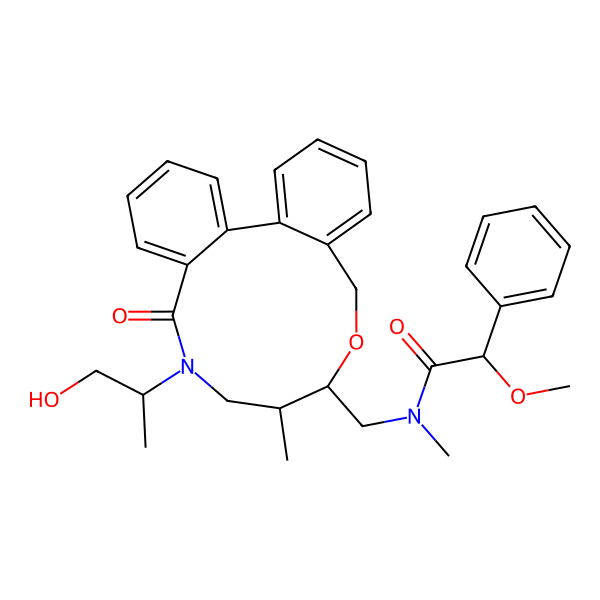

In [159]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
s = df_val['SMILES_standard'].iloc[102]
mol = Chem.MolFromSmiles(s)

drawer = rdMolDraw2D.MolDraw2DSVG(600, 600)  # width, height in px
drawer.DrawMolecule(mol)
drawer.FinishDrawing()
svg = drawer.GetDrawingText()

# Save to file
drawer = rdMolDraw2D.MolDraw2DCairo(600, 600)
drawer.DrawMolecule(mol)
drawer.FinishDrawing()

with open("query.png", "wb") as f:
    f.write(drawer.GetDrawingText())

# You can display SVG inline in Jupyter too:
from IPython.display import SVG, display
display(SVG(svg))

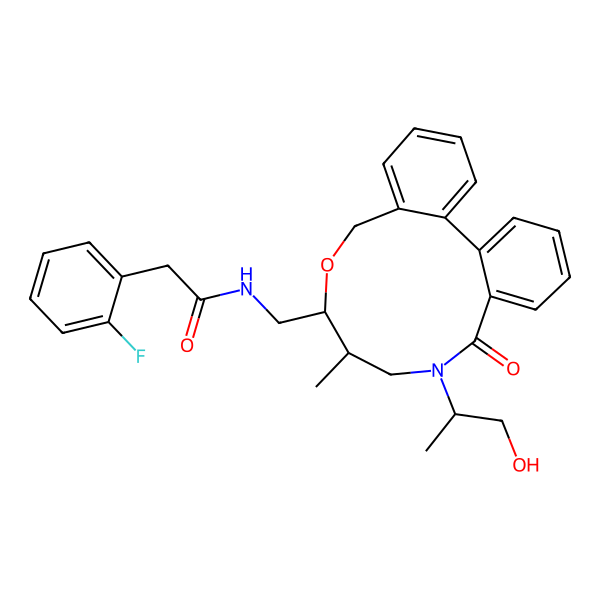

In [158]:
s = smiles[sims.argmax()]
mol = Chem.MolFromSmiles(s)
drawer = rdMolDraw2D.MolDraw2DSVG(600, 600)  # width, height in px
drawer.DrawMolecule(mol)
drawer.FinishDrawing()
svg = drawer.GetDrawingText()

# Save to file
drawer = rdMolDraw2D.MolDraw2DCairo(600, 600)
drawer.DrawMolecule(mol)
drawer.FinishDrawing()

with open("generated27.png", "wb") as f:
    f.write(drawer.GetDrawingText())

# You can display SVG inline in Jupyter too:
from IPython.display import SVG, display
display(SVG(svg))

## Analysis of perturbation data

In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet ('/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/data/df_main_wconditions.parquet')

In [51]:
# df_uncond = df[df['has_condition']==False].sample(n=94105, random_state=42) 

In [41]:
df_cond = df[(df['has_condition']==True) & (df.seq_len<=72)]

In [42]:
df_cond.iloc[:,-1450:-1]

,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_AreaShape_Compactness,Cells_AreaShape_Eccentricity,Cells_AreaShape_Extent,Cells_AreaShape_FormFactor,Cells_AreaShape_MajorAxisLength,Cells_AreaShape_MaxFeretDiameter,Cells_AreaShape_MaximumRadius,Cells_AreaShape_MeanRadius,...,Nuclei_Texture_Variance_ER_10_0,Nuclei_Texture_Variance_ER_3_0,Nuclei_Texture_Variance_ER_5_0,Nuclei_Texture_Variance_Mito_10_0,Nuclei_Texture_Variance_Mito_3_0,Nuclei_Texture_Variance_Mito_5_0,Nuclei_Texture_Variance_RNA_10_0,Nuclei_Texture_Variance_RNA_3_0,Nuclei_Texture_Variance_RNA_5_0,has_condition
41,2.314919,0.746245,0.790115,-0.014804,-2.220936,0.015262,-0.282345,-0.310876,-0.926161,-0.601916,...,-1.975379,-1.537216,-1.694384,-2.010195,-1.523325,-1.923111,-0.721703,-0.715398,-0.727716,True
42,-0.777379,0.149887,2.828240,2.061217,-2.516237,-0.103453,0.728947,0.757317,-0.692783,-0.723258,...,-1.541783,-1.810282,-1.424348,-2.175736,-3.025378,-2.738477,-0.819643,-0.848581,-0.999255,True
43,1.287664,0.146628,0.995885,1.502253,-0.916408,-0.380869,0.500023,0.554712,-0.798817,-0.851473,...,2.077431,1.447079,1.966638,-0.810950,-1.186248,-0.916034,0.138561,0.185454,0.275543,True
44,0.621796,0.337245,0.130425,0.323302,-0.552423,-1.016340,1.149204,1.183307,2.179151,2.056098,...,-0.544909,-0.861115,-1.197857,-0.804342,-0.327998,-0.195914,-1.334798,-1.339023,-1.545277,True
103,0.032902,0.858443,-0.996262,-1.051054,0.485349,0.572209,-0.888975,-0.802617,-0.155826,0.302925,...,-0.257138,0.040612,0.642153,1.675547,1.192460,1.617220,0.153353,-0.475143,-0.231460,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1569903,-0.044966,0.049962,2.003443,1.462058,-2.275085,1.534041,-0.090299,-0.136641,-0.914476,-1.140678,...,-0.797883,-0.593471,-0.493009,-1.244405,-2.110788,-1.836207,-1.274073,-2.301869,-1.711431,True
1570027,-0.773197,0.030659,0.041698,0.520923,0.615781,-0.224689,-1.836850,-1.662979,-1.473157,-1.897050,...,-0.457203,-0.602982,-0.547415,0.718081,0.439811,0.590267,-0.874343,-0.684231,-0.800881,True
1570028,-0.733509,0.846420,0.543788,0.525275,0.361519,1.308120,0.009190,-0.258397,-0.416540,-0.271687,...,2.295507,2.995736,2.664799,2.127725,1.240653,2.348788,1.051124,0.903840,1.239163,True
1570029,-0.483217,-0.301368,-0.085434,0.466976,0.764928,0.660188,-2.544781,-3.071886,-3.545717,-2.660706,...,1.984188,1.634704,1.497178,2.264390,1.183333,1.384463,2.857784,2.155025,3.448053,True


In [43]:
cond_data = df_cond.iloc[:, -1450:-1]

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()
cond_scaled = scaler.fit_transform(np.array(cond_data))
pca = PCA(n_components=2)  
cond_pca = pca.fit_transform(cond_scaled)

In [45]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
cluster_labels = kmeans.fit_predict(cond_pca)
centroids = kmeans.cluster_centers_     

In [52]:
len(kmeans.labels_)

94105

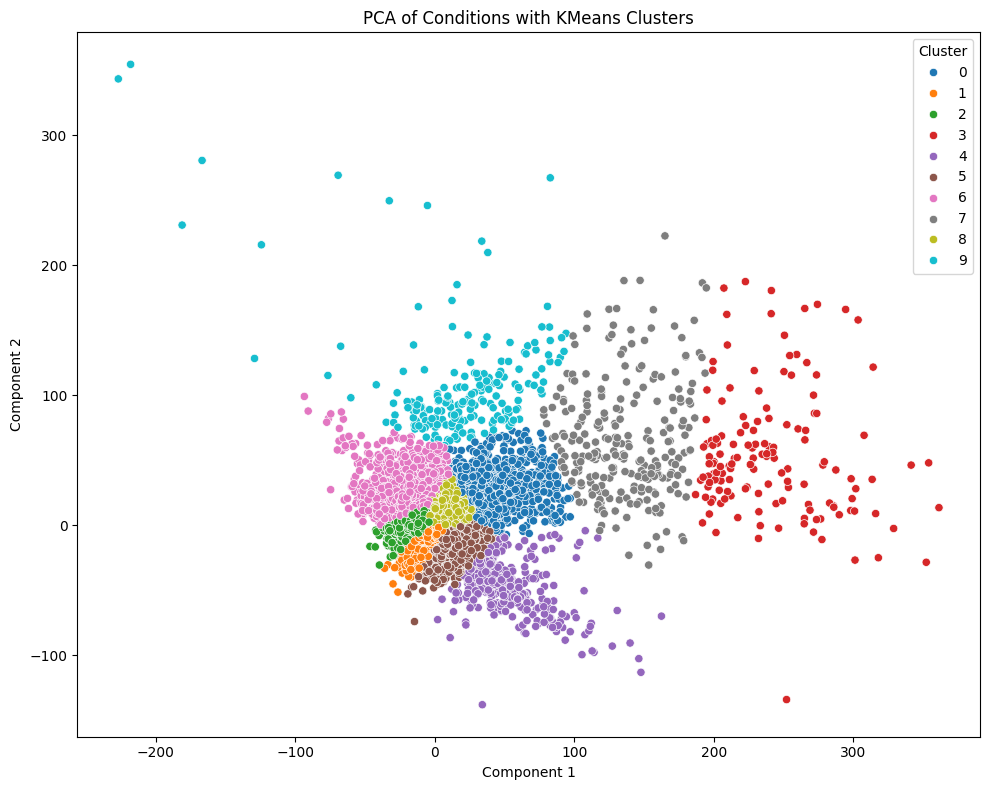

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.scatterplot(x=cond_pca[:, 0], y=cond_pca[:, 1], hue=cluster_labels, palette='tab10')
plt.title("PCA of Conditions with KMeans Clusters")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

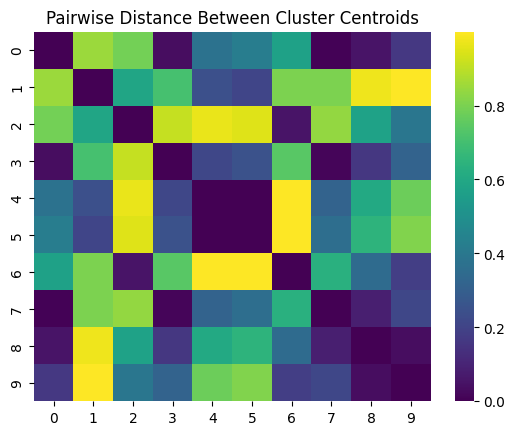

In [48]:
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity

cos_sim = cosine_similarity(centroids)  # range [-1,1]
distance = (1 - cos_sim) / 2  

# Plot as heatmap
sns.heatmap(distance, annot=False, cmap="viridis")
plt.title("Pairwise Distance Between Cluster Centroids")
plt.show()

In [70]:
from collections import Counter
# dmso_cluster_counts = Counter(kmeans.labels_[dmso_ids])

# print("Cluster labels for DMSO samples:", kmeans.labels_[dmso_ids])
# print("DMSO cluster sizes:", dmso_cluster_counts)

In [71]:
cluster_counts = Counter(kmeans.labels_)
print(cluster_counts)

Counter({1: 29896, 2: 23574, 5: 18171, 8: 14286, 6: 6295, 0: 869, 4: 413, 7: 252, 9: 203, 3: 146})


In [67]:
# df['cluster_id'] = -1 

In [57]:
df.loc[(df['has_condition']==True) & (df.seq_len<=72),'cluster_id'] = kmeans.labels_

In [60]:
# Get centroids
centroids = kmeans.cluster_centers_

# Compute distance of each point to its assigned centroid
# Use Euclidean distance here, but can use other metrics if you want
assigned_centroids = centroids[kmeans.labels_]

cos_sim = np.array([
    cosine_similarity(cond_pca[i:i+1], assigned_centroids[i:i+1])[0, 0]
    for i in range(len(cond_pca))
])
cos_dist = (1 - cos_sim) / 2


In [64]:
df['dist_to_centroid'] = -10

In [65]:
df.loc[(df['has_condition']==True) & (df.seq_len<=72),'dist_to_centroid'] = cos_dist

/tmp/ipykernel_3168302/2037270349.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.24658378 0.00285347 0.16233929 ... 0.21203714 0.055399   0.00227289]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df['has_condition']==True) & (df.seq_len<=72),'dist_to_centroid'] = cos_dist


In [66]:
df[(df['has_condition']==True) & (df.seq_len<=72)]

,SMILES_standard,SAFE,safe_tokens,seq_len,encoded,SMILES,Valid,Sanitize,num_atoms,QED,...,Nuclei_Texture_Variance_ER_5_0,Nuclei_Texture_Variance_Mito_10_0,Nuclei_Texture_Variance_Mito_3_0,Nuclei_Texture_Variance_Mito_5_0,Nuclei_Texture_Variance_RNA_10_0,Nuclei_Texture_Variance_RNA_3_0,Nuclei_Texture_Variance_RNA_5_0,has_condition,cluster_id,dist_to_centroid
41,Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,Cc1cc6c2c3c(c5n2n1)c(=O)n(C)c(=O)n3C.c16ccccc1...,"['C', 'c', '1', 'c', 'c', '6', 'c', '2', 'c', ...",56,"[110, 168, 98, 168, 168, 103, 168, 99, 168, 10...",Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,True,True,30,0.458649,...,-1.694384,-2.010195,-1.523325,-1.923111,-0.721703,-0.715398,-0.727716,True,1,0.246584
42,Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,Cc1cc6c2c3c(c5n2n1)c(=O)n(C)c(=O)n3C.c16ccccc1...,"['C', 'c', '1', 'c', 'c', '6', 'c', '2', 'c', ...",56,"[110, 168, 98, 168, 168, 103, 168, 99, 168, 10...",Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,True,True,30,0.458649,...,-1.424348,-2.175736,-3.025378,-2.738477,-0.819643,-0.848581,-0.999255,True,1,0.002853
43,Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,Cc1cc6c2c3c(c5n2n1)c(=O)n(C)c(=O)n3C.c16ccccc1...,"['C', 'c', '1', 'c', 'c', '6', 'c', '2', 'c', ...",56,"[110, 168, 98, 168, 168, 103, 168, 99, 168, 10...",Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,True,True,30,0.458649,...,1.966638,-0.810950,-1.186248,-0.916034,0.138561,0.185454,0.275543,True,8,0.162339
44,Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,Cc1cc6c2c3c(c5n2n1)c(=O)n(C)c(=O)n3C.c16ccccc1...,"['C', 'c', '1', 'c', 'c', '6', 'c', '2', 'c', ...",56,"[110, 168, 98, 168, 168, 103, 168, 99, 168, 10...",Cc1cc(-c2ccccc2)c2c3c(c(-c4ccccc4)n2n1)c(=O)n(...,True,True,30,0.458649,...,-1.197857,-0.804342,-0.327998,-0.195914,-1.334798,-1.339023,-1.545277,True,2,0.015785
103,CCn1c(COc2ccccc2C)nnc1SCC(=O)CC(=O)Nc1ccccc1OC,n19c%10nnc1%11.c15ccccc1C.C7C(=O)CC3=O.c18cccc...,"['n', '1', '9', 'c', '%10', 'n', 'n', 'c', '1'...",69,"[169, 98, 106, 168, 3, 169, 169, 168, 98, 4, 9...",CCn1c(COc2ccccc2C)nnc1SCC(=O)CC(=O)Nc1ccccc1OC,True,True,32,0.346904,...,0.642153,1.675547,1.192460,1.617220,0.153353,-0.475143,-0.231460,True,8,0.009278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1569903,O=C(Cn1cc2c(n1)CCCC2)Nc1cc(-c2cccc(Cl)c2)no1,n15cc2c(n1)CCCC2.c16cccc(Cl)c1.c14cc6no1.O=C3C...,"['n', '1', '5', 'c', 'c', '2', 'c', '(', 'n', ...",50,"[169, 98, 102, 168, 168, 99, 168, 93, 169, 98,...",O=C(Cn1cc2c(n1)CCCC2)Nc1cc(-c2cccc(Cl)c2)no1,True,True,25,0.773000,...,-0.493009,-1.244405,-2.110788,-1.836207,-1.274073,-2.301869,-1.711431,True,1,0.039737
1570027,CCC(C)(C)n1nnnc1CN(Cc1ccc(Cl)cc1)Cc1ccco1,c18ccc(Cl)cc1.n15nnnc16.CCC5(C)C.c17ccco1.N234...,"['c', '1', '8', 'c', 'c', 'c', '(', 'Cl', ')',...",57,"[168, 98, 105, 168, 168, 168, 93, 111, 94, 168...",CCC(C)(C)n1nnnc1CN(Cc1ccc(Cl)cc1)Cc1ccco1,True,True,26,0.589794,...,-0.547415,0.718081,0.439811,0.590267,-0.874343,-0.684231,-0.800881,True,5,0.007604
1570028,CCC(C)(C)n1nnnc1CN(Cc1ccc(Cl)cc1)Cc1ccco1,c18ccc(Cl)cc1.n15nnnc16.CCC5(C)C.c17ccco1.N234...,"['c', '1', '8', 'c', 'c', 'c', '(', 'Cl', ')',...",57,"[168, 98, 105, 168, 168, 168, 93, 111, 94, 168...",CCC(C)(C)n1nnnc1CN(Cc1ccc(Cl)cc1)Cc1ccco1,True,True,26,0.589794,...,2.664799,2.127725,1.240653,2.348788,1.051124,0.903840,1.239163,True,8,0.212037
1570029,CCC(C)(C)n1nnnc1CN(Cc1ccc(Cl)cc1)Cc1ccco1,c18ccc(Cl)cc1.n15nnnc16.CCC5(C)C.c17ccco1.N234...,"['c', '1', '8', 'c', 'c', 'c', '(', 'Cl', ')',...",57,"[168, 98, 105, 168, 168, 168, 93, 111, 94, 168...",CCC(C)(C)n1nnnc1CN(Cc1ccc(Cl)cc1)Cc1ccco1,True,True,26,0.589794,...,1.497178,2.264390,1.183333,1.384463,2.857784,2.155025,3.448053,True,0,0.055399


In [68]:
# df.to_parquet("/lustre/groups/ml01/workspace/ghaith.mqawass/2025_ghaith_de_novo_design/data/df_main_wconditions_clustered.parquet")

In [42]:
# cols_to_add = [col for col in df_cond.columns if col != 'SMILES_standard']

# # Merge with df_main on 'smiles', left join keeps all df_main rows
# df_merged = df_main.merge(df_cond[['SMILES_standard'] + cols_to_add], on='SMILES_standard', how='left') # fill nans where empty

In [32]:
#extact vocab.josn from df in case it gets lost
# import pandas as pd
# df['safe_tokens'] = df['safe_tokens'].apply(ast.literal_eval)
# df['encoded_trimmed'] = df.apply(lambda row: row['encoded'][:len(row['safe_tokens'])], axis=1)
# # Explode both columns
# df_exploded = df[['safe_tokens', 'encoded_trimmed']].explode(['safe_tokens', 'encoded_trimmed'])

# # Drop duplicates to get unique token ↔ id pairs
# unique_pairs = df_exploded.drop_duplicates(subset=['safe_tokens', 'encoded_trimmed'])

# # Build dictionaries
# TOK2ID = dict(zip(unique_pairs['safe_tokens'], unique_pairs['encoded_trimmed']))
# ID2TOK = {v: k for k, v in TOK2ID.items()}

# print(f"Number of unique tokens: {len(TOK2ID)}")
# print(list(TOK2ID.items())[:20])


Number of unique tokens: 171
[('C', 110), ('=', 107), ('(', 93), ('c', 168), ('1', 98), ('5', 102), (')', 94), ('O', 115), ('2', 99), ('.', 96), ('6', 103), ('3', 100), ('8', 105), ('s', 172), ('9', 106), ('n', 169), ('7', 104), ('4', 101), ('N', 114), ('S', 117)]
